# Water Quality ML in Nuevo León

This Jupyter notebook reproduces the machine learning analysis for classifying Water Quality Index (WQI) categories using REMANECA data from Nuevo León, Mexico, as detailed in the preprint:

> Corona-Romero, K., Fumagal-González, G., Garcia-Ceja, E., & González-Mendoza, M. (2025). "Water Quality Classification via Cost-Efficient Machine Learning: A Case Study in Nuevo León." Preprint available at [GitHub Repository](https://github.com/kaledcorona/water-quality-classification-paper).

**TL;DR Summary**: Accurate water quality monitoring is essential but often limited by high laboratory costs. Using 1,302 preprocessed REMANECA samples (2012–2024) from Nuevo León, the study computes WQI via a weighted multiplicative model based on 11 physicochemical features. Five classifiers (Random Forest, SVM, Decision Tree, KNN, Naive Bayes) are evaluated, with Random Forest performing best (accuracy: 0.921 ± 0.023; weighted F1: 0.912 ± 0.028). Feature importance highlights total hardness, coliforms, nutrients (PO₄, NO₃⁻, NH₃), and pH. A cost-aware five-indicator panel (hardness, PO₄, pH, NH₃, SST) maintains strong performance (RF accuracy: 0.857 ± 0.026; weighted F1: 0.829 ± 0.030), though minority-class recall drops. Errors mostly occur between adjacent categories, preserving detection of severe contamination (recall: 98% → 97%). The work proposes a tiered screening strategy to expand monitoring coverage under fixed budgets while ensuring reliable identification of heavily contaminated water.

For full methodology, results interpretation, discussion, and references, refer to the preprint. This notebook focuses on reproducible code for data preprocessing, WQI calculation, model training, feature selection, and evaluation. Setup instructions are in the repository's `README.md`.

## Setup 

In [9]:
# Standard library imports
import os
import re
from pathlib import Path

# Data science and visualization libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from scipy.stats import zscore

# Scikit-learn imports
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    precision_recall_fscore_support,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFECV

figures_dir = Path("../../results/figures")
tables_dir = Path("../../results/tables")


# Print versions for reproducibility
print("Library Versions:")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"numpy: {np.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"scipy: {scipy.__version__}")

Library Versions:
pandas: 2.2.2
scikit-learn: 1.6.1
numpy: 2.0.2
seaborn: 0.13.2
matplotlib: 3.10.0
scipy: 1.16.1


## Data Loading and Preprocessing

Original data can be found in `data/raw/RESULTADOS-NUEVO LEÓN.xlsb` (see `/data/README.md`). We extract the three sheets that the file contains (*data*, *definitions*, *stations*) into CSV that can be found in `data/processed/`.

In [10]:
# Load data
data_dir = Path("../../data/processed/")

path_stations = data_dir / "remaneca_nuevoLeon_sitios.csv"
remaneca_nuevo_leon_stations = pd.read_csv(path_stations)  # Localization data

path_description = data_dir / "remaneca_nuevoLeon_simbologia.csv"
remaneca_nuevo_leon_descriptions = pd.read_csv(path_description) # Features description

path_data = data_dir / "remaneca_nuevoLeon_datos.csv"
remaneca_nuevo_leon_data = pd.read_csv(path_data, low_memory=False) # Physicochemical data



---


### Data Inspection


Once the datasets are loaded, we take a first look at the data.   

We check for:
- the data types assigned by the loader
- any missing values
- data collection frequency
- data distribution

Pandas provides tools to inspect a DataFrame.  
The `info()` method shows the number of rows and features, along with the data type and count for each column.  


After running the code, we find:
- 4,140 rows and 198 features
- 70 numeric features
- 1 integer feature
- 127 features recognized as objects

In [11]:
remaneca_nuevo_leon_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Columns: 198 entries, CLAVE SITIO to ST
dtypes: float64(70), int64(1), object(127)
memory usage: 6.3+ MB


We analyze the **stations** dataset with the same method.  
Since it has fewer features than the **data** table, the output lists details for each one.  

We notice that many features are detected as objects.

In [12]:
remaneca_nuevo_leon_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLAVE SITIO             163 non-null    object 
 1   NOMBRE DEL SITIO        163 non-null    object 
 2   CUENCA                  123 non-null    object 
 3   CLAVE ACUÍFERO          40 non-null     float64
 4   ACUÍFERO                40 non-null     object 
 5   ORGANISMO CUENCA        163 non-null    object 
 6   DIRECCIÓN LOCAL         0 non-null      float64
 7   ESTADO                  163 non-null    object 
 8   MUNICIPIO               163 non-null    object 
 9   CUERPO DE AGUA          163 non-null    object 
 10  TIPO DE CUERPO DE AGUA  163 non-null    object 
 11  SUBTIPO CUERPO AGUA     163 non-null    object 
 12  LATITUD                 163 non-null    float64
 13  LONGITUD                163 non-null    float64
dtypes: float64(4), object(10)
memory usage: 18

Finally, we look at the **description** dataset, which contains only three features:
- **Clave Parámetro**: the identifier linked to each feature
- **Nombre Parámetro**: a description of the feature
- **Unidad de medida**: the unit in which the parameter was measured

In [13]:
remaneca_nuevo_leon_descriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CLAVE PARÁMETRO   192 non-null    object
 1   NOMBRE PARÁMETRO  192 non-null    object
 2   UNIDAD DE MEDIDA  192 non-null    object
dtypes: object(3)
memory usage: 4.6+ KB


From this inspection, we see that features with the object data type may contain mixed values.
This often happens when a column includes both text and numbers, or when missing values are present.



---

We now check for missing values in the dataset and their proportions.  

Pandas provides the `.isna()` method, which returns a boolean matrix showing whether each valuue is missing (`True`) or not (`False`).  

To calculate the percentage of missing values, we can sum all missing entries and divide by the total number of observations.  

This can be expressed as:

$$\frac{\sum_{x=x_1}^{x_n} \text{isna(x)}}{\text{number of observations}}$$

Where $x_1$ is the first feature and $x_n$ the last.  

In practice, we ues the `.mean()` method to calculate the percentage of missing values.


In [14]:
# Compute the fraction of missing values per feature
missing_fraction = remaneca_nuevo_leon_data.isna().mean()

To explore how missing values are distributed, we use a histogram.  

With Seaborn's `histplot()` function, we can pass in a vector and plot its histogram.  

The chart shows a large peak on the right, meaning many features have a high percentage of missing values. There is also a gap between 30% and 85%, where no features fall. This pattern will help us choose a threshold for removing features with too many missing values.

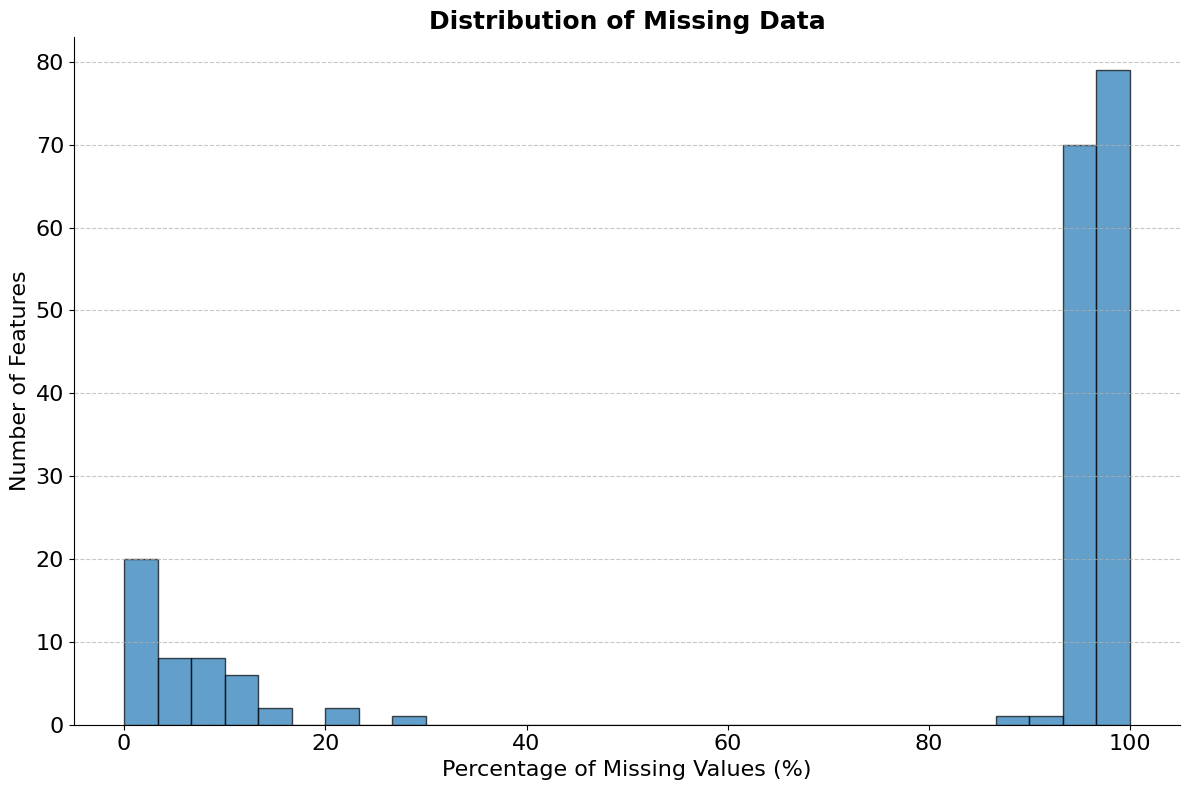

In [15]:
# Histogram of missing values in data remaneca
plt.figure(figsize=(12,8))
plt.hist(missing_fraction * 100, bins=30, alpha=0.7, edgecolor="black")

plt.xlabel("Percentage of Missing Values (%)", fontsize=16)
plt.ylabel("Number of Features", fontsize=16)
plt.title("Distribution of Missing Data", fontsize=18, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)\

plt.tight_layout()
plt.savefig(figures_dir / "histogram_missing_values" ,dpi=300, bbox_inches="tight")
plt.show()

Next, we analyze how the data is distributed across stations.  

In [16]:
# Coerce timestamp to datetime, and extract year
remaneca_nuevo_leon_data["FECHA REALIZACIÓN"] = pd.to_datetime(remaneca_nuevo_leon_data["FECHA REALIZACIÓN"], errors="coerce")
remaneca_nuevo_leon_data["Year"] = remaneca_nuevo_leon_data["FECHA REALIZACIÓN"].dt.year

We count the number of samples for each station, as well as the number of records collected each year.  

We found that the coverage is from 2012 to 2024, with the peak years to be 2013 (653 observations), 2018 (649), and 2015 (605). In addition, the binomial distribution shows to peaks, one around 40 and another close to 5.

In [17]:
# Count samples by station and sambles by year
samples_per_station = remaneca_nuevo_leon_data.groupby("CLAVE SITIO").size().reset_index(name="Count")
samples_station_year = remaneca_nuevo_leon_data.groupby(["Year"]).size().reset_index(name="Count")

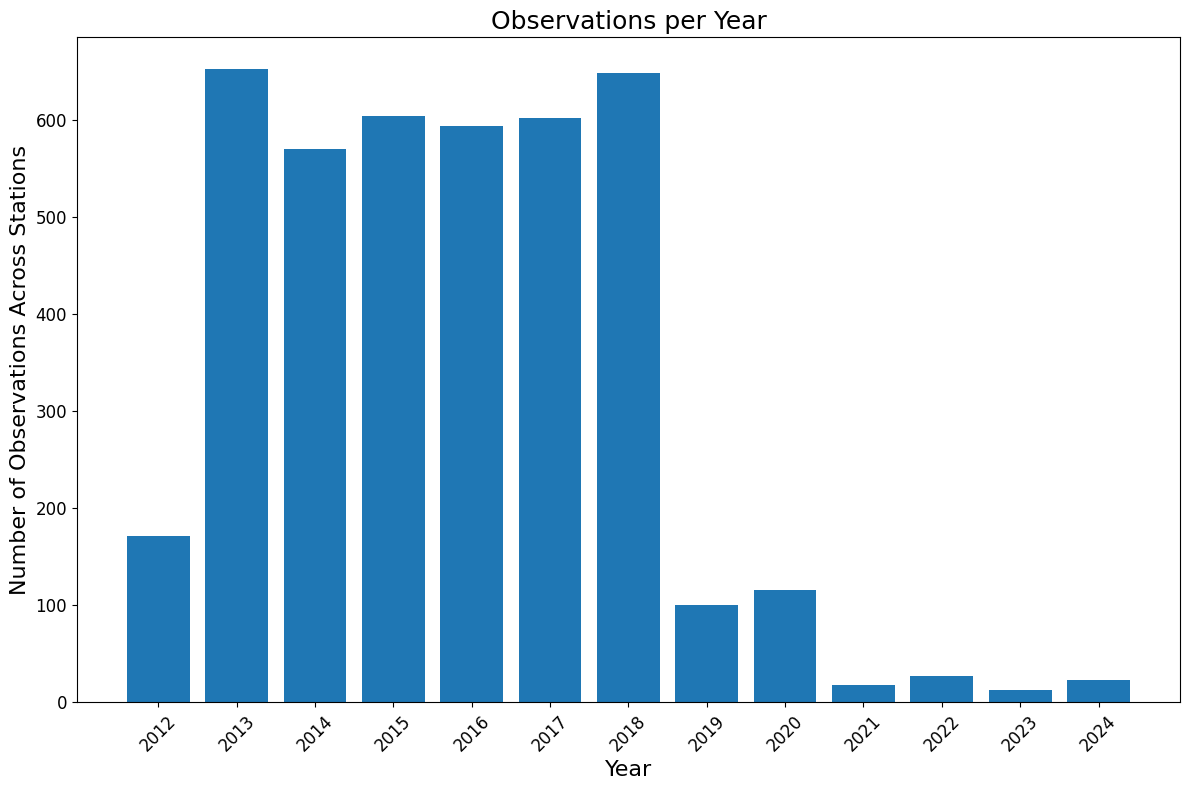

In [18]:
# Plot bar chart of observations per year
plt.figure(figsize=(12,8))
plt.bar(samples_station_year["Year"].astype(str), samples_station_year["Count"])
plt.title("Observations per Year", fontsize=18)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Number of Observations Across Stations", fontsize=16)
plt.xticks(rotation=45)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(figures_dir / "barplot_observations_per_year", dpi=300, bbox_inches="tight")
plt.show()

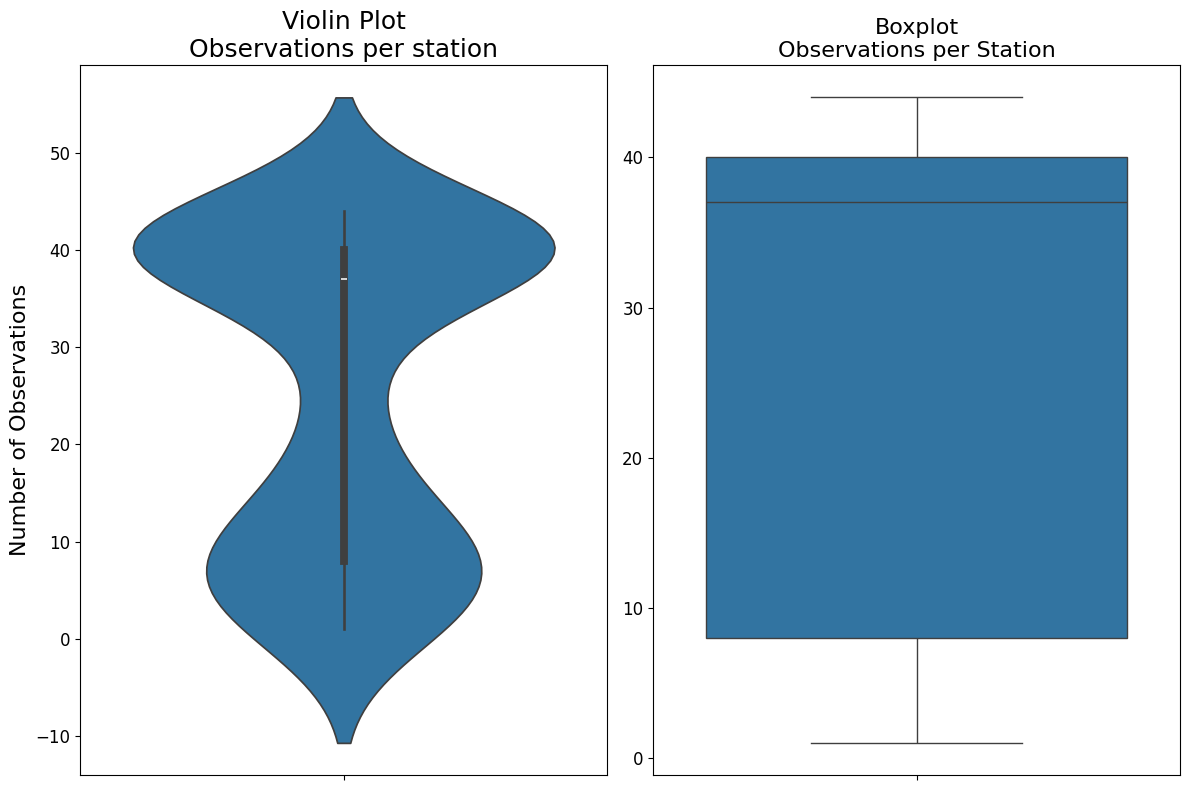

In [19]:
# Plot bar chart of observations per station
plt.figure(figsize=(12,8))

# Violin plot
plt.subplot(1,2,1)
sns.violinplot(y=samples_per_station["Count"], inner="box")
plt.title("Violin Plot\nObservations per station", fontsize=18)
plt.ylabel("Number of Observations", fontsize=16)
plt.tick_params(axis='both', labelsize=12)

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(y=samples_per_station["Count"])
plt.title("Boxplot\nObservations per Station", fontsize=16)
plt.ylabel("")

plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(figures_dir / "violinplot_observations_per_station", dpi=300, bbox_inches="tight")
plt.show()

Let's check which stations are underrepresented.  

We found that 50 stations have less thatn 10 observations between 2012 to 2024

In [20]:
underrepresented = samples_per_station[samples_per_station["Count"] < 10]
print(f"Number of underrepresented stations: {underrepresented.shape[0]}")

Number of underrepresented stations: 50


### Data Cleaning

We cleaned the dataset by removing features with more than 50% missing values. This threshold was choosen after inspecting the histogram of missing values, which showed a clear gap between 35% and 85%. Setting the cutoff at 50% was a natural choice.  

After this step, 151 features were removed, leaving a refined dataset $X' \subset X$, which is  $X' \in \mathbb{R}^{47}$. This smaller, cleaner set was used in the following transformation.  

In [21]:
# Filter columns with <= 50% missingness
retained_columns = missing_fraction[missing_fraction <= 0.5].index
retained_missing_fraction = missing_fraction[retained_columns]

With the features that have less than 50% missing values, we build a DataFrame showing their percentage of missing data for closer inspection.

We also add the description of each retained feature to better understand their meaning.

In [22]:
retained_missing_fraction_df = pd.DataFrame({
    'feature': retained_missing_fraction.index,
    'missing_pct': (retained_missing_fraction.values * 100).round(2)
}).merge(
        remaneca_nuevo_leon_descriptions,
        left_on='feature',
        right_on='CLAVE PARÁMETRO',
        how='left'
    )[['feature', 'NOMBRE PARÁMETRO', 'missing_pct']].rename(columns={'NOMBRE PARÁMETRO': 'description'})

We inspect the new data set by sorting in descending order the features to explore the 10 features with more missing values.

We learned that:
- The toxicity group appears in the top 10.
- Cianuros Totales has the largest percentage of missing values.
- Sustancias activas al azul de metileno appears
- Coliformes totales appears

These features might be lacking because they are expensive to measure or expensive to measure.

In [23]:
retained_missing_fraction_df.sort_values(by="missing_pct", ascending=False).head(10)

,feature,description,missing_pct
42,CN_TOT,Cianuros Totales,27.15
33,SAAM,Sustancias Activas al Azul de Metileno,23.14
23,TOX_V_30_UT,"Toxicidad Vibrio fischeri, 30min",20.43
46,CAUDAL,Caudal,15.39
7,COLI_TOT,Coliformes Totales,14.08
31,OD_%,Oxígeno Disuelto_%,11.84
22,TOX_V_15_UT,Toxicidad Vibrio fischeri 15min UT,11.11
21,TOX_D_48_UT,"Toxicidad Daphnia magna, 48 h",11.09
32,OD_mg/L,Oxígeno Disuelto,11.01
13,DQO_SOL,Demanda Química de Oxígeno Soluble,10.51


In addition, we also inspect how the missing values are distributed in this data set.

<Axes: xlabel='missing_pct', ylabel='Count'>

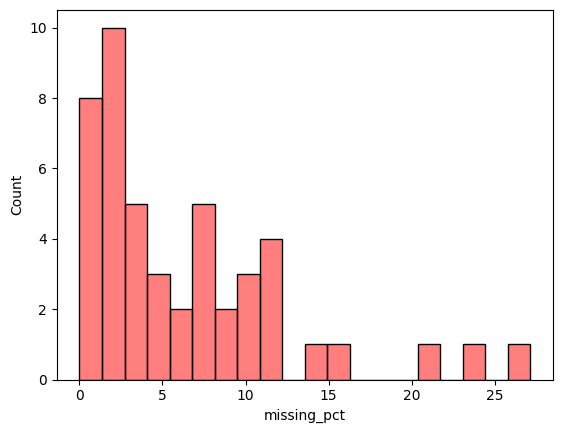

In [24]:
# Histogram of the retained features
sns.histplot(retained_missing_fraction_df['missing_pct'], color="red", alpha=0.5, bins=20)

In addition, we visualize the global distribution of missing values and adding their respective label

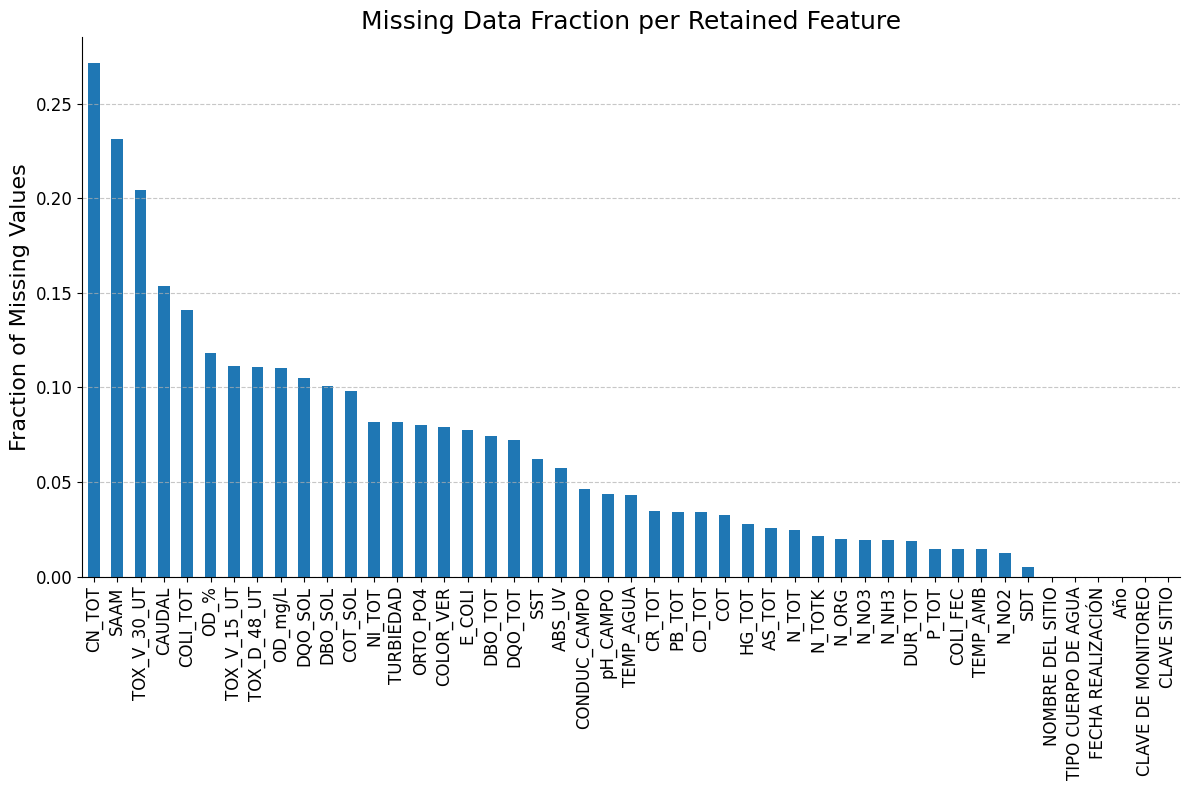

In [26]:
# Barplot of missingness per retained variable
plt.figure(figsize=(12, 8))
retained_missing_fraction.sort_values(ascending=False).plot(kind='bar')
plt.ylabel("Fraction of Missing Values", fontsize=16)
plt.title("Missing Data Fraction per Retained Feature", fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(rotation=90)
plt.tick_params(axis='both', labelsize=12)


for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)


plt.tight_layout()
plt.savefig( figures_dir / "histogram_missingValues_47features", dpi=300, bbox_inches="tight")
plt.show()


We create a subset $X'$ of only the retained features.

In [27]:
# A subset with only the retained features
df_retained = remaneca_nuevo_leon_data[retained_columns]



---


### Data coersion

It is advisable to make sure that the data type representing the features is correct. In Python, features with categoric and numeric data are represented as objects.  

We noticed that many features where recognized as objects with numerical values represented as text strings "<4", ">200" or values with units.

The timestamps and metadata features were straightforward converted to temporal and categorical data respectively.

For numerical features we used the following algorithm to remove non-numeric symbols and standardize missing values.

The first colums are metadata and usually they should be categorical or temporal. We inspect this.

As we take a look, we notice that:
- CLAVE SITIO should be categorical non-ordinal.
- CLAVE MONITOREO is also categorical non-ordinal
- NOMBRE DEL SITIO is also categorical non-ordinal
- TIPO DE AGUA is categorical non-ordinal
- FECHA REALIZACION is temporal
- Año is temporal

In [28]:
df_retained.iloc[:3,:6]

,CLAVE SITIO,CLAVE DE MONITOREO,NOMBRE DEL SITIO,TIPO CUERPO DE AGUA,FECHA REALIZACIÓN,Año
0,OCRBR0001RNL,OCRBR0001RNL-100223,ARROYO ELIZONDO A LA ALTURA DE LA PILETA DE RE...,LÓTICO,2023-02-10,2023
1,OCRBR0002RNL,OCRBR0002RNL-070323,LAGUNA DE SALINILLAS,LÉNTICO,2023-03-07,2023
2,OCRBR0003RNL,OCRBR0003RNL-230323,ENTRADA LAGUNA DE SALINILLAS,LÉNTICO,2023-03-23,2023


We convert FECHA REALIZACION to temporal type

In [29]:
# Convert feature to datetime
df_retained['FECHA REALIZACIÓN'] = pd.to_datetime(df_retained['FECHA REALIZACIÓN'], dayfirst=False, errors='coerce')

/tmp/ipykernel_7775/438472280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_retained['FECHA REALIZACIÓN'] = pd.to_datetime(df_retained['FECHA REALIZACIÓN'], dayfirst=False, errors='coerce')


Convert the remaining columns to a categorical type

In [30]:
id_cols = ['CLAVE SITIO', 'CLAVE DE MONITOREO', 'NOMBRE DEL SITIO', 'TIPO CUERPO DE AGUA']
df_retained[id_cols] = df_retained[id_cols].apply(lambda s: s.astype('category'))

/tmp/ipykernel_7775/1927738416.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_retained[id_cols] = df_retained[id_cols].apply(lambda s: s.astype('category'))


We still need to convert the features with data type object.
To do this, we identify them using a list comprehension that filters only the columns of type object.

In [31]:
# Columns with object type
obj_cols = [c for c in retained_columns if df_retained[c].dtype == "object"]

We apply the following loop to convert features into strings, standardize decimal point, remove any symbol excluding numbers, and standardize missing values.

In [32]:
for col in obj_cols:
    # Convert features to text
    series = df_retained[col].astype(str)

    # 1) Standardise decimal commas → dots
    cleaned = series.str.replace(",", ".", regex=False)

    # 2) Strip leading "<" or ">" (censored data rule)
    cleaned = cleaned.str.replace(r"^[<>]\s*", "", regex=True)

    # 3) Remove common unit strings (letters, slash, spaces) but keep numbers, dot
    cleaned = cleaned.str.replace(r"[A-Za-zµ/°%\s]+", "", regex=True)

    # 4) Define explicit missing tokens → NaN
    cleaned = cleaned.replace(
        {
            "ND": np.nan,
            "N/D": np.nan,
            "NA": np.nan,
            "--": np.nan,
            "": np.nan,
        },
        regex=False,
    )

    # 5) Coerce to float
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    df_retained[col] = numeric_series


/tmp/ipykernel_7775/3146050530.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_retained[col] = numeric_series
/tmp/ipykernel_7775/3146050530.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_retained[col] = numeric_series
/tmp/ipykernel_7775/3146050530.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

Finally, we verify that the dataset has the correct data types."

In [33]:
df_retained.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 47 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CLAVE SITIO          4140 non-null   category      
 1   CLAVE DE MONITOREO   4140 non-null   category      
 2   NOMBRE DEL SITIO     4140 non-null   category      
 3   TIPO CUERPO DE AGUA  4140 non-null   category      
 4   FECHA REALIZACIÓN    4140 non-null   datetime64[ns]
 5   Año                  4140 non-null   int64         
 6   COLI_FEC             4080 non-null   float64       
 7   COLI_TOT             3557 non-null   float64       
 8   E_COLI               3819 non-null   float64       
 9   COT                  4006 non-null   float64       
 10  COT_SOL              3734 non-null   float64       
 11  DBO_SOL              3722 non-null   float64       
 12  DBO_TOT              3833 non-null   float64       
 13  DQO_SOL              3699 non-nul



---


### Data imputation

Fewer than half of the features still have missing values.  
We handle these by imputing the median per station and per year. If any gaps remain, we fill them with the station's overall median.

We impute missing data using the median, following three steps:
1. Fill missing values with the median for each station and year.
2.  If gaps remain, use the median for the station.
3.  If any are still missing, replace them with the global median.   


On average, 296 observations were imputed per column (around 7\% of data).

First, we create a subset of the dataset that keeps only the numeric features

In [34]:
df_numeric = df_retained.select_dtypes(include="number")

Select the feature names, exluding the year (Año)

In [35]:
# Identify numeric colums except year
numeric_cols = [c for c in df_numeric.columns if c not in ("Año",)]

We now use the algorithm to fill in missing values with the median

In [36]:
# Impute with medians and summarize imputation coverage
summary = []
n_rows = len(df_retained)

for col in numeric_cols:
    col_series = df_retained[col]
    before_na = col_series.isna().sum()
    if before_na == 0:
        summary.append({
            "Variable": col,
            "Missing Before": 0,
            "Missing After": 0,
            "Imputed Values": 0,
            "% Imputed (of column)": 0.0,
            "% Resolved (of missing)": 0.0,
            "Imputed @ station-year": 0,
            "Imputed @ station": 0,
            "Imputed @ global": 0
        })
        continue

    # Track masks to count what each step fills
    m0 = col_series.isna()

    # 1) station-year median
    station_year_med = df_retained.groupby(["CLAVE SITIO", "Año"])[col].transform("median")
    filled1 = col_series.fillna(station_year_med)
    m1 = filled1.isna()
    step1_imputed = int((m0 & ~m1).sum())

    # 2) station median
    station_med = df_retained.groupby("CLAVE SITIO")[col].transform("median")
    filled2 = filled1.fillna(station_med)
    m2 = filled2.isna()
    step2_imputed = int((m1 & ~m2).sum())

    # 3) global median
    global_med = filled2.median(skipna=True)
    filled3 = filled2.fillna(global_med)
    m3 = filled3.isna()
    step3_imputed = int((m2 & ~m3).sum())

    # Assign back
    df_retained[col] = filled3

    after_na = int(m3.sum())
    imputed = int(before_na - after_na)

    summary.append({
        "Variable": col,
        "Missing Before": int(before_na),
        "Missing After": int(after_na),
        "Imputed Values": imputed,
        "% Imputed (of column)": round(100 * imputed / n_rows, 2),
        "% Resolved (of missing)": round(100 * imputed / before_na, 2),
        "Imputed @ station-year": step1_imputed,
        "Imputed @ station": step2_imputed,
        "Imputed @ global": step3_imputed
    })

summary_df = (
    pd.DataFrame(summary)
      .sort_values("Imputed Values", ascending=False)
      .reset_index(drop=True)
)


/tmp/ipykernel_7775/2556166487.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_year_med = df_retained.groupby(["CLAVE SITIO", "Año"])[col].transform("median")
/tmp/ipykernel_7775/2556166487.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_med = df_retained.groupby("CLAVE SITIO")[col].transform("median")
/tmp/ipykernel_7775/2556166487.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

The summary confirms that all missing values have been successfully filled

- We imputed 27.15 % for CN_TOT, 23% for SAAM, and 20% for TOX_V_30_UT

In [37]:
summary_df

,Variable,Missing Before,Missing After,Imputed Values,% Imputed (of column),% Resolved (of missing),Imputed @ station-year,Imputed @ station,Imputed @ global
0,CN_TOT,1124,0,1124,27.15,100.0,424,423,277
1,SAAM,958,0,958,23.14,100.0,429,508,21
2,TOX_V_30_UT,846,0,846,20.43,100.0,27,401,418
3,CAUDAL,637,0,637,15.39,100.0,154,65,418
4,COLI_TOT,583,0,583,14.08,100.0,24,141,418
5,OD_%,490,0,490,11.84,100.0,50,80,360
6,TOX_V_15_UT,460,0,460,11.11,100.0,13,29,418
7,TOX_D_48_UT,459,0,459,11.09,100.0,14,54,391
8,OD_mg/L,456,0,456,11.01,100.0,51,89,316
9,DQO_SOL,441,0,441,10.65,100.0,35,157,249




---


### Data Analysis

Now that the data has been imputed, let’s take a look at how it appears.

We use the pandas `describe()` method to get a summary of the numerical features with common statistical metrics.  

From this, we notice that many features show large standard deviations, which may suggest the presence of outliers.

In [38]:
df_retained.select_dtypes(include="number").describe()

,Año,COLI_FEC,COLI_TOT,E_COLI,COT,COT_SOL,DBO_SOL,DBO_TOT,DQO_SOL,DQO_TOT,...,CD_TOT,CR_TOT,HG_TOT,NI_TOT,PB_TOT,CN_TOT,DUR_TOT,TEMP_AMB,TEMP_AGUA,CAUDAL
count,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,...,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000
mean,2015.709179,5612.717874,8117.641787,4573.197343,3.866173,2.956675,3.213372,6.885727,17.084568,31.087398,...,0.001480,0.005090,0.000333,0.004601,0.003135,0.005435,643.664356,27.735744,25.216616,1856.401998
std,2.230055,10305.327333,9654.204739,9747.191502,5.811492,3.952575,4.709944,16.787089,15.514274,76.339025,...,0.001889,0.014422,0.001197,0.010617,0.011328,0.009384,657.483122,6.284876,4.479567,13771.880512
min,2012.000000,1.000000,1.000000,1.000000,0.103000,0.103000,2.000000,2.000000,10.000000,5.000000,...,0.000130,0.000900,0.000090,0.000420,0.001540,0.001000,24.600000,0.000000,5.500000,0.200000
25%,2014.000000,93.000000,930.000000,90.000000,1.090075,1.010000,2.000000,2.000000,10.000000,10.000000,...,0.001301,0.001200,0.000201,0.000420,0.001540,0.001600,307.752750,24.200000,22.300000,198.000000
50%,2016.000000,930.000000,2400.000000,430.000000,2.284000,1.880350,2.000000,2.000000,10.000000,14.900000,...,0.001301,0.001200,0.000201,0.000420,0.001540,0.003000,477.407000,29.300000,26.000000,481.950000
75%,2017.000000,4600.000000,24000.000000,2400.000000,4.530000,3.412025,2.200000,6.360000,19.000000,31.160000,...,0.001301,0.002500,0.000201,0.005413,0.001540,0.005907,779.910000,32.200000,28.400000,1200.000000
max,2024.000000,241960.000000,24196.000000,241960.000000,153.820000,72.050000,146.400000,370.000000,248.000000,3336.000000,...,0.050800,0.326400,0.057340,0.222400,0.178100,0.272000,12188.000000,40.600000,43.400000,561000.000000


We select the columns with numerical values

In [39]:
# Select only numerical features
numeric_df = df_retained.select_dtypes(include='number')

and then visualize them with grouped boxplots

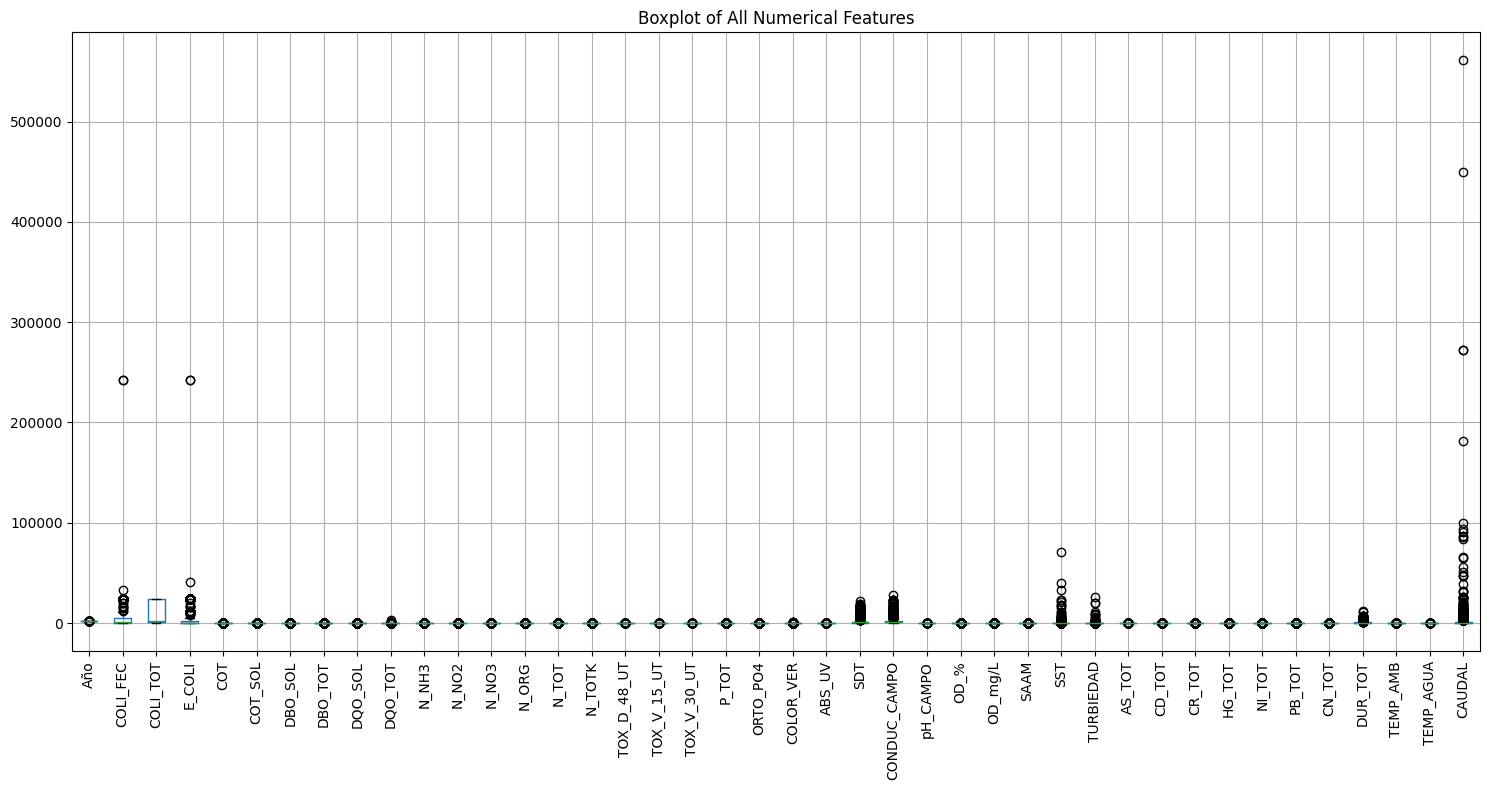

In [40]:
plt.figure(figsize=(15,8))
numeric_columns = numeric_df.columns
numeric_df[numeric_columns].boxplot(rot=90)
plt.title('Boxplot of All Numerical Features')
plt.tight_layout()
plt.grid(True)
plt.show()

From the plot, we it is easy to see that COLI_FEC, E_COLI, SDT, CONDUC_CAMPO, SST, TURBEDAD, and CAUDAL have many outliers

We filtrate outlier based on the difference between the third quantile and first quantile

In [41]:
# Calculate Q1 and Q3 for IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

We defined outliers to be mild if they are in a range 1.5 greater than the distance from the first and third quantile. Extreme outliers are defined to be a distance of 3 times the difference inter-quantile.

In [42]:
mild_lower_fence = Q1 - 1.5 * IQR
mild_upper_fence = Q3 + 1.5 * IQR
extreme_lower_fence = Q1 - 3 * IQR
extreme_upper_fence = Q3 + 3 * IQR

Use use a mask to filter mild and extreme values, so that they are in the previous defined range

In [43]:
# Detect outliers using IQR method
mild_outliers = ((numeric_df > mild_upper_fence) & (numeric_df <= extreme_upper_fence)) | \
                ((numeric_df < mild_lower_fence) & (numeric_df >= extreme_lower_fence))
extreme_outliers = (numeric_df > extreme_upper_fence) | (numeric_df < extreme_lower_fence)


The percentage of outliers were first calculated

In [44]:
# Calculate percentages
mild_outlier_percentage = mild_outliers.sum() / len(numeric_df) * 100
extreme_outlier_percentage = extreme_outliers.sum() / len(numeric_df) * 100


Finally, we combine the percentage of mild and extreme outliers with the feature which corresponds

In [45]:
# Combine into one DataFrame
outlier_types_df = pd.DataFrame({
    'Feature': numeric_df.columns,
    'Mild_Outlier_Percentage': mild_outlier_percentage.values,
    'Extreme_Outlier_Percentage': extreme_outlier_percentage.values
})

Showing the data set of mild and extreme outliers. Notice that HG_TOT has the most percentage of extreme values, followed by DBO and E.coli

In [46]:
outlier_types_df.sort_values(by='Extreme_Outlier_Percentage', ascending=False).head(10)

,Feature,Mild_Outlier_Percentage,Extreme_Outlier_Percentage
34,HG_TOT,0.000000,27.898551
6,DBO_SOL,1.835749,20.990338
3,E_COLI,0.072464,18.067633
1,COLI_FEC,0.144928,17.681159
33,CR_TOT,4.975845,16.280193
10,N_NH3,2.681159,16.111111
28,SAAM,4.323671,11.932367
20,ORTO_PO4,6.159420,10.628019
15,N_TOTK,5.410628,10.531401
29,SST,4.347826,7.946860


We create a mask to identify those values

In [47]:
# Identify rows without any extreme outliers
rows_without_extreme_outliers = ~((numeric_df < extreme_lower_fence) | (numeric_df > extreme_upper_fence)).any(axis=1)


Finally, we filter the data set using this mask

In [48]:
# Filter the original dataframe
df_clean = df_retained[rows_without_extreme_outliers]


We boxplot the data set to look how many outliers remains. We notice that changing the threshold just slightly increasing it removes a big percentage of rows, so we decide to accept that the data  naturally have outliers. We decided this because using the threshold removed more than the half of the rows in the dataset.

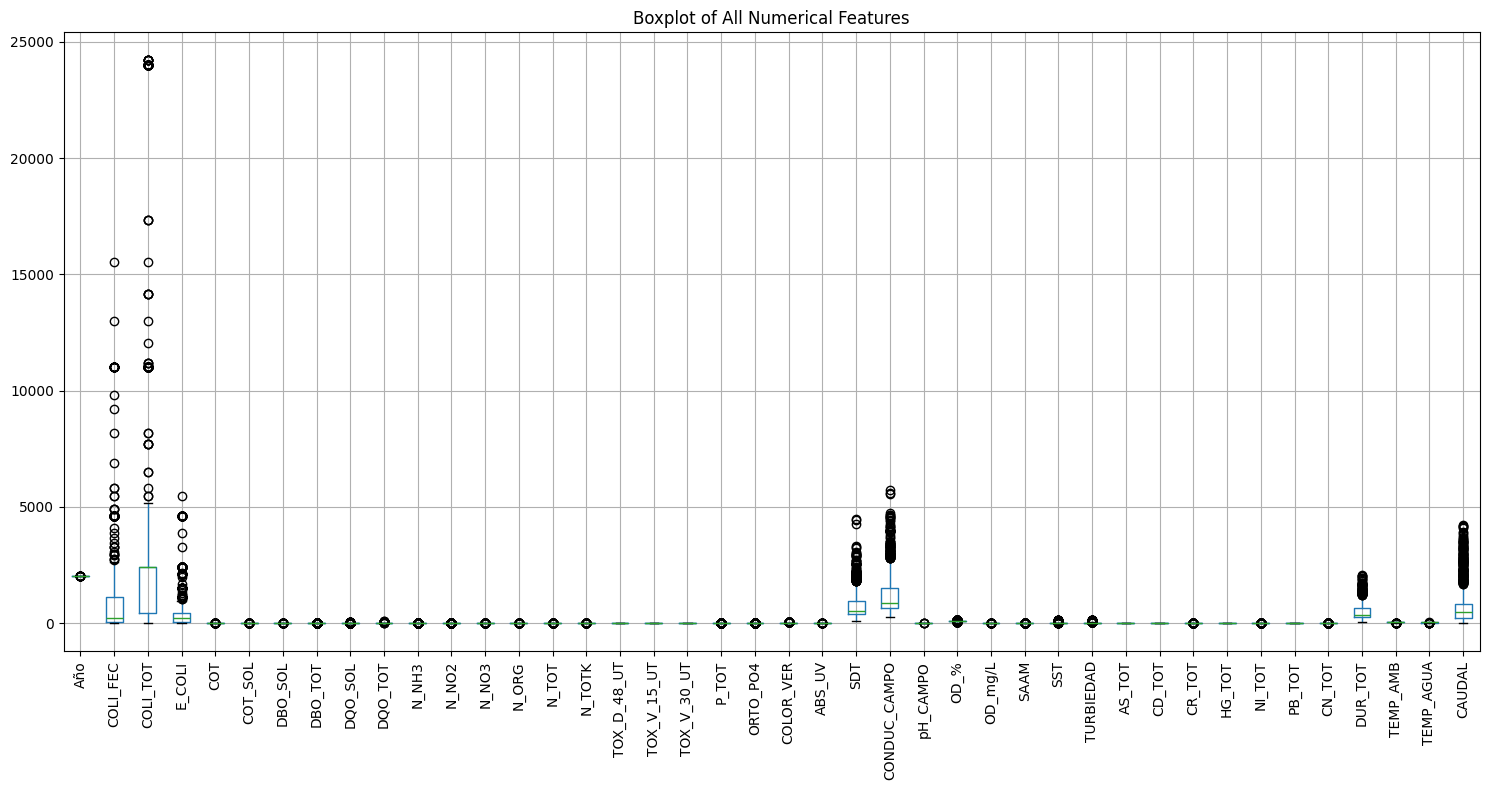

In [49]:
plt.figure(figsize=(15,8))
numeric_columns = df_clean.select_dtypes(include='number').columns
df_clean[numeric_columns].boxplot(rot=90)
plt.title('Boxplot of All Numerical Features')
plt.tight_layout()
plt.grid(True)
plt.show()

See the histogram of each feature

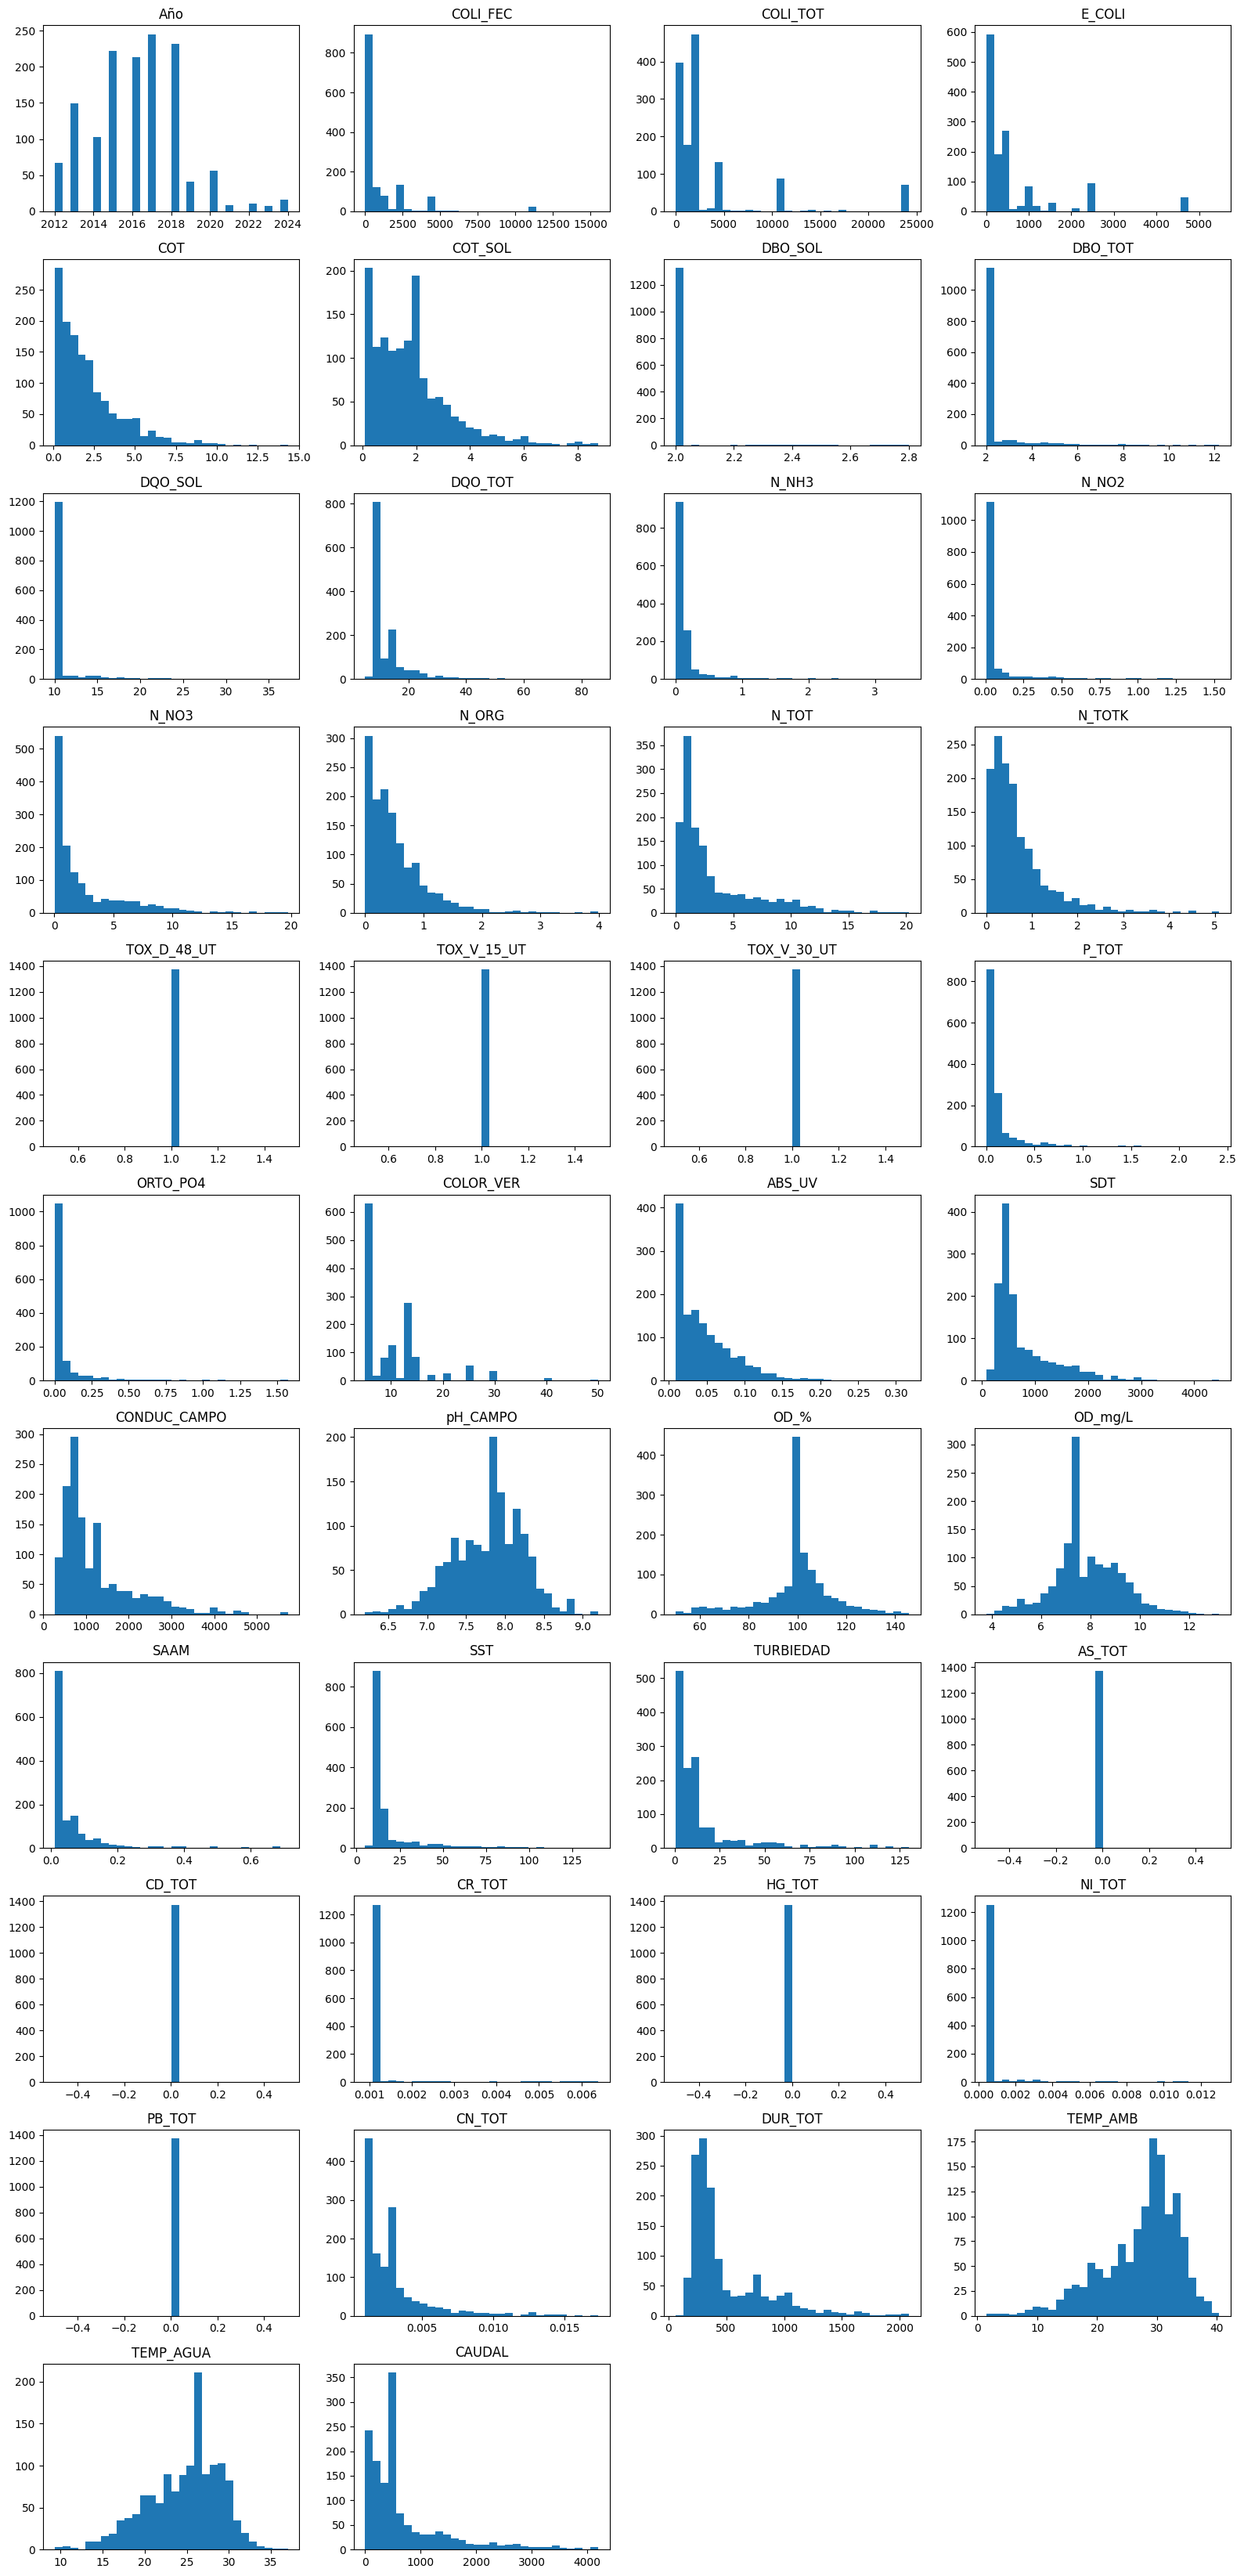

In [50]:
num_cols = df_clean.select_dtypes(include=np.number).columns
# Grid like R's par(mfrow)
n = len(num_cols)
cols = 4                         # change to taste
rows = int(np.ceil(n / cols))

ax = df_clean[num_cols].hist(
    bins=30,
    layout=(rows, cols),
    figsize=(cols*4, rows*3),
    grid=False,
    sharex=False,                # keep scales independent
    sharey=False
)

plt.tight_layout()
plt.savefig(figures_dir / "histogram_retainedfeatures_clean", dpi=300, bbox_inches="tight")
plt.show()

Let's explore if any observations from underrepresented stations exists.

In [51]:
# Count samples by station and sambles by year
samples_per_station_clean = df_clean.groupby("CLAVE SITIO").size().reset_index(name="Count")
samples_station_year_clean = df_clean.groupby(["Año"]).size().reset_index(name="Count")

/tmp/ipykernel_7775/1302469724.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_station_clean = df_clean.groupby("CLAVE SITIO").size().reset_index(name="Count")


We see that there are 44 observations in total from years 2021 to 2024, which are insignificant. Because we are unable to generalize to those years, we decided to removed the observations from those years.

In [52]:
samples_station_year_clean

,Año,Count
0,2012,67
1,2013,149
2,2014,103
3,2015,222
4,2016,213
5,2017,245
6,2018,232
7,2019,41
8,2020,56
9,2021,9


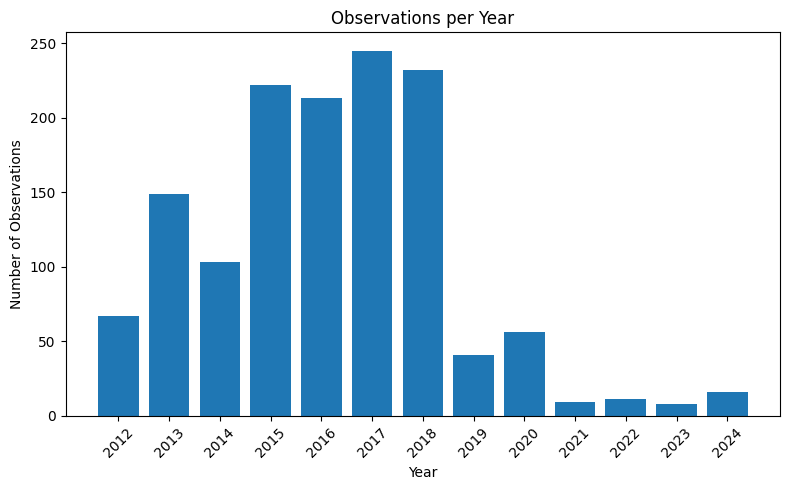

In [53]:
# Plot bar chart of observations per year
plt.figure(figsize=(8,5))
plt.bar(samples_station_year_clean["Año"].astype(str), samples_station_year_clean["Count"])
plt.title("Observations per Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We take a look to the number of under-represented stations, which are considered as smaller than the first quantile.

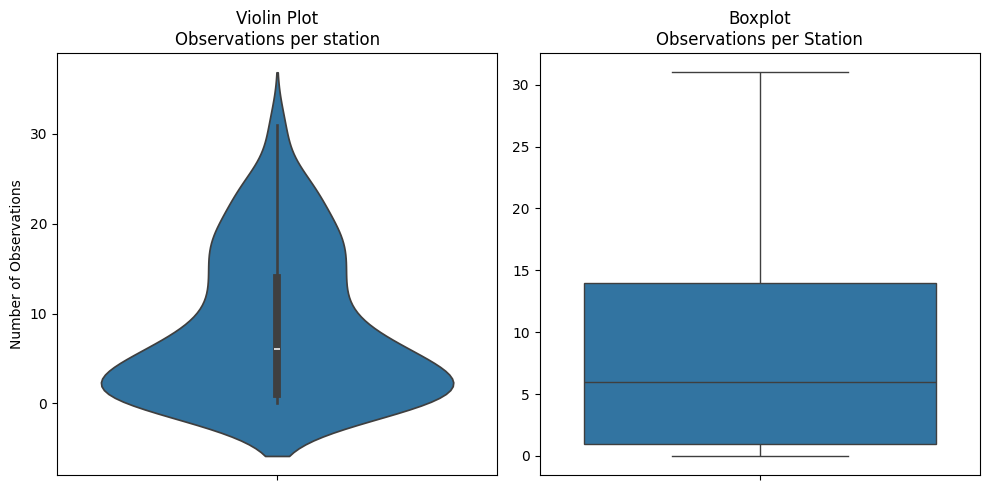

In [54]:
# Plot bar chart of observations per station
plt.figure(figsize=(10,5))

# Violin plot
plt.subplot(1,2,1)
sns.violinplot(y=samples_per_station_clean["Count"], inner="box")
plt.title("Violin Plot\nObservations per station")
plt.ylabel("Number of Observations")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(y=samples_per_station_clean["Count"])
plt.title("Boxplot\nObservations per Station")
plt.ylabel("")

plt.tight_layout()
plt.show()

We empirically choose to remove stations with less than 3 observations.

In [55]:
underrepresented_clean = samples_per_station_clean[samples_per_station_clean["Count"] < 3]
print(f"Number of underrepresented stations: {underrepresented_clean.shape[0]}")

Number of underrepresented stations: 52


We are going to remove underrepresented stations.

In [56]:
# Identify underrepresented stations
underrepresented = samples_per_station_clean.query("Count < 3")

# Keep only stations with enough samples
well_represented = samples_per_station_clean.query("Count >= 3")

# Filter the main dataset by station IDs
df_clean = df_clean[df_clean["CLAVE SITIO"].isin(well_represented["CLAVE SITIO"])]

The shape after removing the stations

In [57]:
df_clean.shape

(1338, 47)

The shape after removing years 2021 to 2024

In [58]:
# Remove observations from years 2021–2024
df_clean = df_clean[~df_clean["Año"].between(2021, 2024)]

In [59]:
df_clean.shape

(1302, 47)



---


### Feature selection


The 47 features were narrowed down to a smaller set based on prior domain knowledge. The Water Quality Index (ICA) is then calculated using a weighted multiplicative aggregation framework, first proposed by Dinius (1987) and later adapted to Mexican water monitoring standards by León Vizcaíno (1974)[1](https://www.scielo.org.mx/scielo.php?pid=S0188-49992023000100114&script=sci_arttext).  

This index condenses multiple physicochemical and microbiological indicators into a single score from 0 to 100, making interpretation, trend analysis, and decision-making more straightforward.

To reflect the different importance of each parameter for overall water quality, a dimensionless weight $W_i \in [0,1]$ is assigned. These weights are defined through expert consensus and empirical validation, and together they sum to one:

$$
\sum_{i=1}^{n} W_i = 1
$$

The overall ICA is calculated as the weighted geometric mean of the $Q_i$ values:

\begin{equation}
ICA = \prod_{i=1}^{n} Q_i^{W_i}
\end{equation}

where:

- $Q_i$ is the quality score assigned to parameter $i$ as a function of its measured concentration.
- $W_i$ is the relative weight reflecting the environmental and health significance of parameter $i$.

He propose to use the following features (table extracted from his article [link](https://www.dspace.espol.edu.ec/bitstream/123456789/6147/1/ICA%20Forma%20de%20estimarlos.pdf)):

| Parameter                          | Unit        | Value of $w_i$ |
| ---------------------------------- | ----------- | -------------- |
| Dissolved Oxygen                   | % Sat.      | 0.103          |
| Biochemical Oxygen Demand (BOD)    | mg/L        | 0.096          |
| Chemical Oxygen Demand (COD)       | mg/L        | 0.053          |
| pH                                 | —           | 0.063          |
| Suspended Solids                   | mg/L        | 0.033          |
| Total Coliforms                    | #/100 mL    | 0.083          |
| Fecal Coliforms                    | #/100 mL    | 0.143          |
| Nitrates                           | mg/L        | 0.053          |
| Ammonium                           | mg/L        | 0.043          |
| Phosphates                         | mg/L        | 0.073          |
| Phenols                            | µg/L        | 0.033          |
| Temperature Difference             | °C          | 0.043          |
| Alkalinity (as CaCO₃)              | mg/L        | 0.055          |
| Hardness (as CaCO₃)                | mg/L        | 0.058          |
| Chlorides                          | mg/L        | 0.068          |



He proposed using 15 features. We tried to match these with our dataset and found that only 11 were available.

We then select the following features that were available

In [60]:
# ICA parameter columns
ica_cols = [
    "OD_%",
    "DBO_SOL",
    "DQO_SOL",
    "pH_CAMPO",
    "SST",
    "COLI_TOT",
    "COLI_FEC",
    "N_NO3",
    "N_NH3",
    "ORTO_PO4",
    "DUR_TOT",
]

Select a subset with  only the required columns defined in ica_columns


In [61]:
# Subset dataframe
subset_cols = [c for c in ica_cols if c in df_clean.columns]
df_subset = df_clean[subset_cols].copy()

The calibration points used in the ICA curves were chosen to reflect critical ecological and health thresholds reported in the literature (Dinius, 1987; Vizcaíno, 1974). For each parameter, values corresponding to poor (0) and excellent (100) water quality were fixed, with additional intermediate knots capturing nonlinear sensitivity. For example, dissolved oxygen below 20% saturation is assigned a score of 0, while ≥90% corresponds to 100. Variables such as pH and hardness, which penalize both extremes, are modeled with U-shaped curves around their optimal windows.

In [62]:
curves = {
    # ----------------- Beneficial variable (higher is better) --------------
    # Dissolved oxygen (% saturation) — peak ~100% with supersaturation penalty
    "OD_%": [
        (20,  10),     # severe hypoxia still >0
        (40,  25),
        (60,  50),
        (80,  75),
        (90,  90),
        (100, 100),    # peak near full saturation
        (120, 90),     # supersaturation penalty
        (140, 50),
    ],

    # ----------------- Harmful variables (lower is better) -----------------
    # Biochemical Oxygen Demand (mg/L)
    "DBO_SOL": [
        (30,   0),
        (15,  25),
        ( 8,  50),
        ( 5,  75),
        ( 3, 100),
    ],

    # Chemical Oxygen Demand (mg/L) — pragmatic local calibration
    "DQO_SOL": [
        (300,  0),
        (140, 25),
        ( 70, 50),
        ( 40, 75),
        ( 20,100),
    ],

    # Suspended Solids, TSS (mg/L)
    "SST": [
        (400,  0),
        (150, 25),
        ( 75, 50),
        ( 40, 75),
        ( 20,100),
    ],

    # Total coliforms (CFU/100 mL)
    "COLI_TOT": [
        (100000, 0),
        ( 20000,25),
        (  5000,50),
        (  1000,60),
        (    200,70),
        (0, 100),
    ],

    # Fecal coliforms (CFU/100 mL)
    "COLI_FEC": [
        (100000, 0),
        ( 20000,25),
        (  5000,50),
        (  1000,60),
        (    200,70),
        (0, 100),
    ],

    # Nitrate
        "N_NO3": [
        (100,   2),
        ( 40,  10),
        ( 15,  25),
        ( 10,  70),      # added
        (  7,  80),
        (  3,  90),
        (  1, 100),
    ],

    # Ammonia
    "N_NH3": [
        (5.0,  0),
        (2.0, 25),
        (1.0, 50),
        (0.5, 75),
        (0.1,100),
    ],

    # Orthophosphate, as PO4-P (mg/L)
    "ORTO_PO4": [
        (1.00,   0),
        (0.40,  25),
        (0.20,  50),
        (0.10,  70),
        (0.05,  80),
        (0.00, 100),
    ],

    # ----------------- Two–sided variables ---------------------------------
    # pH — optimum around neutrality, penalties on both acidic and alkaline ends
    "pH_CAMPO": [
        (2.0,  0),
        (5.0, 25),
        (6.0, 50),
        (6.5, 75),
        (7.2, 95),
        (7.4,100),
        (7.6, 95),
        (8.5, 75),
        (9.0, 50),
        (10.0,25),
        (12.0, 0),
    ],

    # Total hardness — U-shaped: very soft or very hard water is penalised
    "DUR_TOT": [
        (   0,  0),     # ultra-soft, no buffering capacity
        (  20, 25),
        (  80,100),     # optimal window ~80–120
        ( 120,100),
        ( 200, 75),
        ( 300, 50),
        ( 450, 25),
        ( 600,  0),
    ],
}


We defined a function that interpolates between the specified points on each curve, so that any new measurement can be mapped smoothly onto the function

In [63]:
def piecewise_q(x, knots):
    xs, qs = zip(*knots)
    """
    knots = [(x0, q0), (x1, q1), ...] sorted by x.
    Linear interpolation between knots, clipping outside.
    """
    if xs[0] > xs[-1]:
        xs, qs = xs[::-1], qs[::-1]
    return np.interp(x, xs, qs, left=qs[0], right=qs[-1])


We then applied this function to each feature to generate its corresponding quality index values

In [64]:
# Generate the Quality index Qi for all features
Qi_df = pd.DataFrame({
    col: piecewise_q(df_subset[col].astype(float).values, knots)
    for col, knots in curves.items()
}, index=df_subset.index)


In addition, we use the weights defined by León Vizcaíno. His framework included 15 features for calculating the water quality index, but our dataset contains only 11 of them. To ensure consistency, we rescaled the available weights so that their sum equals one.

In [65]:
weights = {
    "OD_%": 0.103, "DBO_SOL": 0.096, "DQO_SOL": 0.053, "pH_CAMPO": 0.063,
    "SST": 0.033, "COLI_TOT": 0.083, "COLI_FEC": 0.143, "N_NO3": 0.053,
    "N_NH3": 0.043, "ORTO_PO4": 0.073, "DUR_TOT": 0.058,
}

# Sum of the kept weights
total = sum(weights.values())

# Scaled weights that now sum to 1
scaled_weights = {k: v / total for k, v in weights.items()}

We store the weights as a NumPy array for easier computation

In [66]:
w = np.array([scaled_weights[c] for c in Qi_df.columns])

Finally, we compute the ICA as a sum of logarithms, and later use exponentiation

In [67]:
# Compute ICA
ln_ica = (np.log(Qi_df.clip(lower=1e-6)) * w).sum(axis=1)
df_subset["ICA_Dinius"] = np.exp(ln_ica)




We also use the same water quality index classification for irrigation. The categories are defined as follows:

* **Excellent (E, 90-100):** No purification required for irrigation.
* **Acceptable (A, 70-90):** Minor purification may be needed for crops requiring high-quality water.
* **Slightly Contaminated (LC, 50-70):** Usable for most crops.
* **Contaminated (C, 30-50):** Requires treatment before use with most crops.
* **Heavily Contaminated (FC, 20-30):** Suitable only for very resistant crops.
* **Excessively Contaminated (EC, 0-20):** Inappropriate for irrigation.



In [68]:
# Irrigation classification
def class_irrig(ica):
    if ica >= 90:
        return "E"
    elif ica >= 70:
        return "A"
    elif ica >= 50:
        return "LC"
    elif ica >= 30:
        return "C"
    elif ica >= 20:
        return "FC"
    else:
        return "EC"


We apply such classification to the ICA index and saved it as a new feature

In [69]:
df_subset["ICA_Class_Riego"] = df_subset["ICA_Dinius"].apply(class_irrig)

In [70]:
df_subset.head(5)

,OD_%,DBO_SOL,DQO_SOL,pH_CAMPO,SST,COLI_TOT,COLI_FEC,N_NO3,N_NH3,ORTO_PO4,DUR_TOT,ICA_Dinius,ICA_Class_Riego
23,113.3,2.0,10.00,8.4,15.00,11000.0,930.0,8.885100,0.149900,0.023500,1507.000,20.650230,FC
27,97.2,2.0,10.00,7.6,13.00,930.0,430.0,2.998253,0.123326,0.009507,1349.380,22.868724,FC
32,108.7,2.0,14.40,8.1,12.30,930.0,930.0,6.070350,0.150850,0.036100,1673.560,21.822512,FC
35,62.9,2.0,17.00,7.7,11.33,2400.0,2400.0,4.918220,0.910000,0.160270,1161.540,18.752318,EC
39,56.2,2.0,15.37,7.7,12.00,11000.0,4600.0,6.711400,2.051996,0.254430,1497.123,16.155939,EC


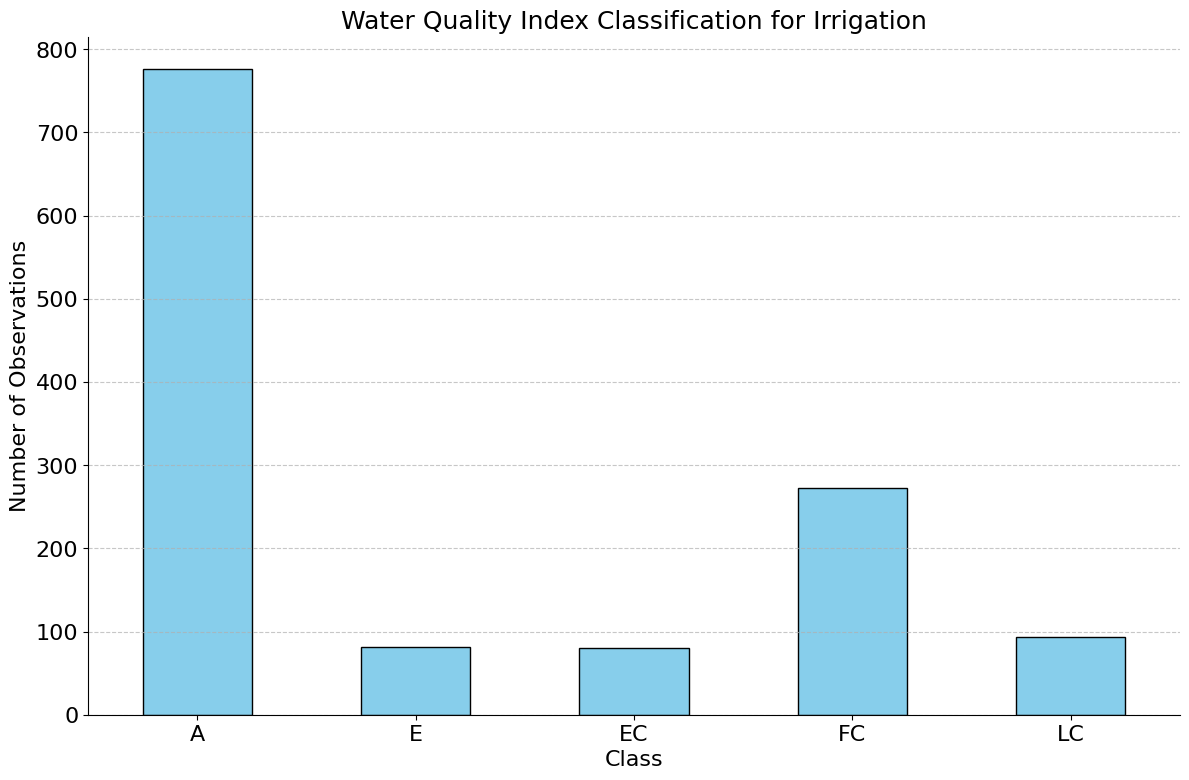

In [71]:
class_counts = df_subset["ICA_Class_Riego"].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(12,8))
class_counts.plot(kind="bar", color="skyblue", edgecolor="black")

# Titles and labels
plt.title("Water Quality Index Classification for Irrigation", fontsize=18)
plt.xlabel("Class", fontsize=16)
plt.ylabel("Number of Observations", fontsize=16)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)\

plt.tight_layout()
plt.savefig(figures_dir / "barplot_wqi_samples" ,dpi=300, bbox_inches="tight")


# Display
plt.xticks(rotation=0)
plt.show()

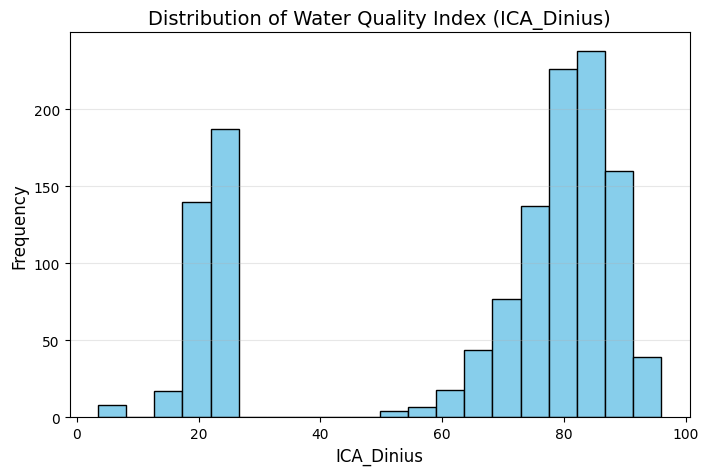

In [72]:
plt.figure(figsize=(8,5))
plt.hist(df_subset["ICA_Dinius"], bins=20, color="skyblue", edgecolor="black")

plt.title("Distribution of Water Quality Index (ICA_Dinius)", fontsize=14)
plt.xlabel("ICA_Dinius", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.savefig(figures_dir / "histogram_wqi", dpi=300, bbox_inches="tight")
plt.show()

Let add the year and station to the dataset

In [73]:
df_subset["CLAVE SITIO"] = df_clean["CLAVE SITIO"]
df_subset["CLAVE DE MONITOREO"] = df_clean["CLAVE DE MONITOREO"]
df_subset["TIPO CUERPO DE AGUA"] = df_clean["TIPO CUERPO DE AGUA"]
df_subset["FECHA REALIZACIÓN"] = df_clean["FECHA REALIZACIÓN"]
df_subset["Año"] = df_clean["Año"]

In [74]:
df_subset

,OD_%,DBO_SOL,DQO_SOL,pH_CAMPO,SST,COLI_TOT,COLI_FEC,N_NO3,N_NH3,ORTO_PO4,DUR_TOT,ICA_Dinius,ICA_Class_Riego,CLAVE SITIO,CLAVE DE MONITOREO,TIPO CUERPO DE AGUA,FECHA REALIZACIÓN,Año
23,113.3,2.0,10.00,8.4,15.00,11000.0,930.0,8.885100,0.149900,0.023500,1507.0000,20.650230,FC,OCRBR4974M2,OCRBR4974M2-060915,LÓTICO,2015-08-28,2015
27,97.2,2.0,10.00,7.6,13.00,930.0,430.0,2.998253,0.123326,0.009507,1349.3800,22.868724,FC,OCRBR4974M2,OCRBR4974M2-260616,LÓTICO,2016-06-23,2016
32,108.7,2.0,14.40,8.1,12.30,930.0,930.0,6.070350,0.150850,0.036100,1673.5600,21.822512,FC,OCRBR4974M2,OCRBR4974M2-210517,LÓTICO,2017-05-16,2017
35,62.9,2.0,17.00,7.7,11.33,2400.0,2400.0,4.918220,0.910000,0.160270,1161.5400,18.752318,EC,OCRBR4974M2,OCRBR4974M2-240917,LÓTICO,2017-09-18,2017
39,56.2,2.0,15.37,7.7,12.00,11000.0,4600.0,6.711400,2.051996,0.254430,1497.1230,16.155939,EC,OCRBR4974M2,OCRBR4974M2-100618,LÓTICO,2018-06-08,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4111,99.6,2.0,10.00,7.9,14.00,2400.0,3.0,1.531097,0.082742,0.050940,356.6364,85.392702,A,OCRBR5365,OCRBR5365-110218,SUBTERRÁNEO,2018-02-09,2018
4112,99.6,2.0,10.00,8.4,14.00,2400.0,3.0,1.320777,0.276133,0.050940,356.5380,84.029407,A,OCRBR5365,OCRBR5365-231218,SUBTERRÁNEO,2018-12-17,2018
4114,99.6,2.0,10.00,7.4,14.00,2400.0,3.0,3.614700,0.039400,0.050940,416.4440,83.953685,A,OCRBR5366,OCRBR5366-140517,SUBTERRÁNEO,2017-05-08,2017
4115,99.6,2.0,10.00,7.9,14.00,2400.0,3.0,1.708974,0.067722,0.050940,329.7928,85.989888,A,OCRBR5366,OCRBR5366-110218,SUBTERRÁNEO,2018-02-09,2018


Finally, we saved the clean data set.

In [75]:
# Save data set
output_path = data_dir / "remaneca_clean.csv"
df_subset.to_csv(output_path, index=False) #uncomment for save the data set

we rename the dataset as df for later analysis

In [76]:
df = df_subset.copy()



---


### Models




After preprocessing, the data is ready for input into machine learning models. In this experiment, we applied five different classification algorithms

We create a dataframe with only numerical features of interest and the target.

In [77]:
target = ['ICA_Dinius', 'ICA_Class_Riego']

and we drop the metadata features

In [78]:
df_only_feat = df.copy()

We encode the variables as numerical index to improve the performance of the models, and use the function `OrdinalEncoder` to assign each category a number.

In [79]:
# Convert categories to numerical values
categories = [['A', 'LC', 'FC', 'E', 'EC']]
encoder = OrdinalEncoder(categories=categories)

And we transform the ICA categorical features with this encoding

In [80]:
# Transform categories to integers ids
df_only_feat['ICA_Class_Riego'] = encoder.fit_transform(df_only_feat[['ICA_Class_Riego']])

In [81]:
df_only_feat = df_only_feat.drop([
    "CLAVE SITIO",
    "Año",
    "CLAVE DE MONITOREO",
    "TIPO CUERPO DE AGUA",
    "FECHA REALIZACIÓN"], axis=1)

In [82]:
df_only_feat

,OD_%,DBO_SOL,DQO_SOL,pH_CAMPO,SST,COLI_TOT,COLI_FEC,N_NO3,N_NH3,ORTO_PO4,DUR_TOT,ICA_Dinius,ICA_Class_Riego
23,113.3,2.0,10.00,8.4,15.00,11000.0,930.0,8.885100,0.149900,0.023500,1507.0000,20.650230,2.0
27,97.2,2.0,10.00,7.6,13.00,930.0,430.0,2.998253,0.123326,0.009507,1349.3800,22.868724,2.0
32,108.7,2.0,14.40,8.1,12.30,930.0,930.0,6.070350,0.150850,0.036100,1673.5600,21.822512,2.0
35,62.9,2.0,17.00,7.7,11.33,2400.0,2400.0,4.918220,0.910000,0.160270,1161.5400,18.752318,4.0
39,56.2,2.0,15.37,7.7,12.00,11000.0,4600.0,6.711400,2.051996,0.254430,1497.1230,16.155939,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4111,99.6,2.0,10.00,7.9,14.00,2400.0,3.0,1.531097,0.082742,0.050940,356.6364,85.392702,0.0
4112,99.6,2.0,10.00,8.4,14.00,2400.0,3.0,1.320777,0.276133,0.050940,356.5380,84.029407,0.0
4114,99.6,2.0,10.00,7.4,14.00,2400.0,3.0,3.614700,0.039400,0.050940,416.4440,83.953685,0.0
4115,99.6,2.0,10.00,7.9,14.00,2400.0,3.0,1.708974,0.067722,0.050940,329.7928,85.989888,0.0


We split the data into features $X$ and target $y$. This is useful to train a machine learning model in a supervised learning paradigm.



---


#### Training a base line model

We now train a simple model to be used as base line. We use a simple linear regression to see how it behaves with the data.

In [83]:
X = df_only_feat.drop(columns=["ICA_Dinius", "ICA_Class_Riego"], axis=1)
y = df_only_feat["ICA_Dinius"]

We begin by splitting the data into the training and testing set using the function `train_test_split()` from scikit learn

In [84]:
# Split the data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [85]:
X_train.shape

(1041, 11)

In [86]:
X_test.shape

(261, 11)

Then we scalate the normalize the data

In [87]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

We instanciate a linear regresion model using `LinearRegression()` and fit the data

In [88]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Then we make a prediction with the testing set

In [89]:
# Make a prediction
y_pred = model.predict(X_test)

and we calculate the root mean square error, and the adjust coeffient

In [90]:
# Metrics
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

We summarize the results in two tables

In [91]:
# Coefficient table
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

# ------------------------------------------------------------------
# 5. Display metrics and coefficients
# ------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "R²"],
    "Value": [rmse, r2]
})

In [92]:
metrics_df

,Metric,Value
0,RMSE,113.149429
1,R²,0.826307


We see that the coefficient of fitness has a value of $0.82$ it is less than the azar.

Analyzing the coefficients, we can see that PO4 has a negative impact in the water quality, also the pH.

In [93]:
coef_df

,Feature,Coefficient
9,ORTO_PO4,-35.426957
1,DBO_SOL,2.848067
3,pH_CAMPO,-2.307519
8,N_NH3,1.467673
7,N_NO3,0.169105
2,DQO_SOL,0.159943
4,SST,-0.106574
0,OD_%,0.087591
10,DUR_TOT,-0.064577
6,COLI_FEC,-0.000889


#### Testing different models

Now we try different models try predict the category of the water quality index. Each of the models was input into the same pipeline, and its methodology can be seen as follows.

In [94]:
X = df_only_feat.drop(columns=['ICA_Class_Riego','ICA_Dinius'], axis=1)
y = df_only_feat['ICA_Class_Riego']

Again we split and normalize the data

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We instanciate the models we will be using:

In [96]:
models = {
    # random forest: gini, 100 trees, classes are weighted by num of samples,
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    # Knn: k=5
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

We are going to use cross validation to have an accurate measurement of the results. We instanciate them using `StratifiedKFold`

In [97]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Finally, we use the following code to iteratively train different classifiers and print their metrics

In [98]:
def evaluate_models_cv(models, X, y, class_mapping, n_splits=5, random_state=42):
    """
    models: dict like {"Random Forest": RandomForestClassifier(...), ...}
    X, y: pandas objects
    class_mapping: e.g., {0.0: "A", 1.0: "LC", 2.0: "FC", 3.0: "E", 4.0: "EC"}
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    label_order  = list(class_mapping.keys())
    target_names = [class_mapping[k] for k in label_order]

    all_model_summaries = {}

    for name, estimator in models.items():
        pipe = make_pipeline(StandardScaler(), estimator)

        fold_metrics = []
        pooled_true, pooled_pred = [], []

        for tr, te in skf.split(X, y):
            X_tr, X_te = X.iloc[tr], X.iloc[te]
            y_tr, y_te = y.iloc[tr], y.iloc[te]

            pipe.fit(X_tr, y_tr)
            y_hat = pipe.predict(X_te)

            # per-fold metrics
            acc = accuracy_score(y_te, y_hat)
            p_ma, r_ma, f_ma, _ = precision_recall_fscore_support(
                y_te, y_hat, average="macro", zero_division=0
            )
            p_wt, r_wt, f_wt, _ = precision_recall_fscore_support(
                y_te, y_hat, average="weighted", zero_division=0
            )

            fold_metrics.append({
                "accuracy": acc,
                "precision_macro": p_ma,
                "recall_macro": r_ma,
                "f1_macro": f_ma,
                "precision_weighted": p_wt,
                "recall_weighted": r_wt,
                "f1_weighted": f_wt,
            })

            pooled_true.append(y_te)
            pooled_pred.append(y_hat)

        # ---- summarize across folds (mean ± sd) ----
        fm = pd.DataFrame(fold_metrics)
        summary = pd.DataFrame({
            "mean": fm.mean(),
            "std":  fm.std(ddof=1)
        })
        all_model_summaries[name] = summary

        print(f"\n{name} — CV results (mean ± sd)")
        print((summary.applymap(lambda v: f"{v:.3f}")).to_string())

        # ---- pooled predictions across folds ----
        y_true = pd.concat(pooled_true).values
        y_pred = np.concatenate(pooled_pred)

        print("\nPooled classification report:")
        print(classification_report(
            y_true, y_pred,
            labels=label_order,
            target_names=target_names,
            zero_division=0
        ))

        cm = confusion_matrix(y_true, y_pred, labels=label_order)
        ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
            cmap=plt.cm.Blues, values_format="d"
        )
        plt.title(f"{name} — Confusion Matrix (pooled CV)")
        plt.show()

    # nice multi-index dataframe: (model, metric) x (mean, std)
    results_df = pd.concat(all_model_summaries, axis=1).swaplevel(axis=1).sort_index(axis=1)
    return results_df


Random Forest — CV results (mean ± sd)
                     mean    std
accuracy            0.921  0.023
precision_macro     0.926  0.037
recall_macro        0.785  0.073
f1_macro            0.831  0.061
precision_weighted  0.923  0.022
recall_weighted     0.921  0.023
f1_weighted         0.912  0.028

Pooled classification report:
              precision    recall  f1-score   support

           A       0.91      0.99      0.95       776
          LC       0.94      0.54      0.68        93
          FC       0.94      0.98      0.96       272
           E       0.90      0.67      0.77        81
          EC       0.92      0.75      0.83        80

    accuracy                           0.92      1302
   macro avg       0.92      0.79      0.84      1302
weighted avg       0.92      0.92      0.91      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


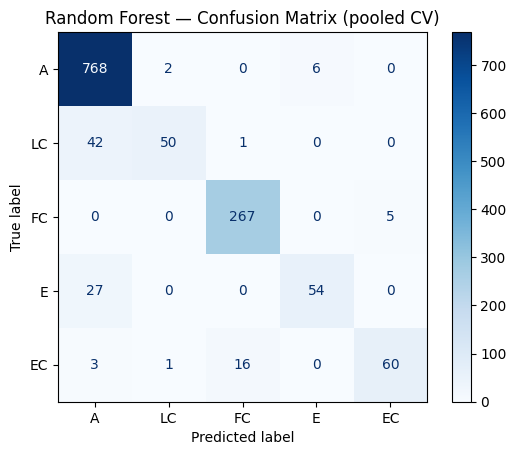


Support Vector Machine — CV results (mean ± sd)
                     mean    std
accuracy            0.866  0.019
precision_macro     0.653  0.037
recall_macro        0.634  0.045
f1_macro            0.635  0.043
precision_weighted  0.810  0.020
recall_weighted     0.866  0.019
f1_weighted         0.833  0.022

Pooled classification report:
              precision    recall  f1-score   support

           A       0.87      0.98      0.92       776
          LC       0.68      0.54      0.60        93
          FC       0.93      0.95      0.94       272
           E       0.00      0.00      0.00        81
          EC       0.78      0.70      0.74        80

    accuracy                           0.87      1302
   macro avg       0.65      0.63      0.64      1302
weighted avg       0.81      0.87      0.83      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


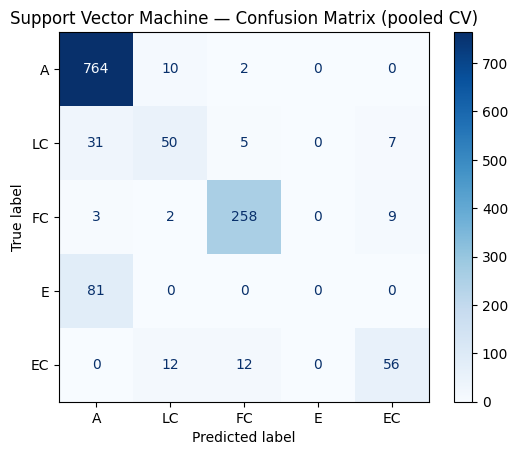


K-Nearest Neighbors — CV results (mean ± sd)
                     mean    std
accuracy            0.822  0.029
precision_macro     0.714  0.077
recall_macro        0.604  0.059
f1_macro            0.641  0.067
precision_weighted  0.809  0.039
recall_weighted     0.822  0.029
f1_weighted         0.808  0.034

Pooled classification report:
              precision    recall  f1-score   support

           A       0.84      0.94      0.89       776
          LC       0.54      0.39      0.45        93
          FC       0.91      0.86      0.89       272
           E       0.45      0.31      0.37        81
          EC       0.82      0.51      0.63        80

    accuracy                           0.82      1302
   macro avg       0.71      0.60      0.64      1302
weighted avg       0.81      0.82      0.81      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


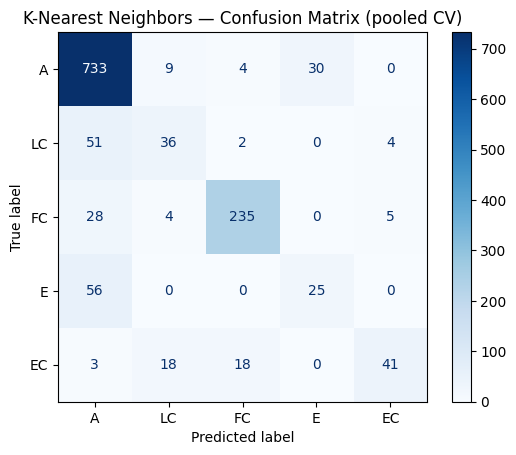


Naive Bayes — CV results (mean ± sd)
                     mean    std
accuracy            0.793  0.039
precision_macro     0.682  0.060
recall_macro        0.815  0.063
f1_macro            0.719  0.060
precision_weighted  0.859  0.032
recall_weighted     0.793  0.039
f1_weighted         0.808  0.036

Pooled classification report:
              precision    recall  f1-score   support

           A       0.98      0.75      0.85       776
          LC       0.50      0.61      0.55        93
          FC       0.81      0.92      0.86       272
           E       0.41      0.94      0.57        81
          EC       0.67      0.85      0.75        80

    accuracy                           0.79      1302
   macro avg       0.67      0.81      0.72      1302
weighted avg       0.86      0.79      0.81      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


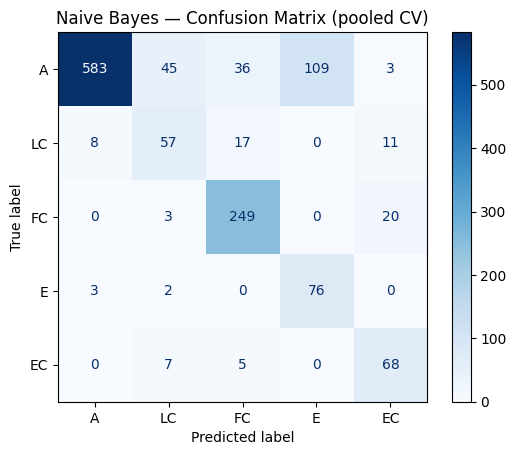


Decision Tree — CV results (mean ± sd)
                     mean    std
accuracy            0.898  0.020
precision_macro     0.829  0.049
recall_macro        0.830  0.036
f1_macro            0.823  0.031
precision_weighted  0.904  0.018
recall_weighted     0.898  0.020
f1_weighted         0.898  0.019

Pooled classification report:
              precision    recall  f1-score   support

           A       0.94      0.93      0.93       776
          LC       0.68      0.72      0.70        93
          FC       0.95      0.95      0.95       272
           E       0.69      0.72      0.70        81
          EC       0.83      0.84      0.83        80

    accuracy                           0.90      1302
   macro avg       0.82      0.83      0.82      1302
weighted avg       0.90      0.90      0.90      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


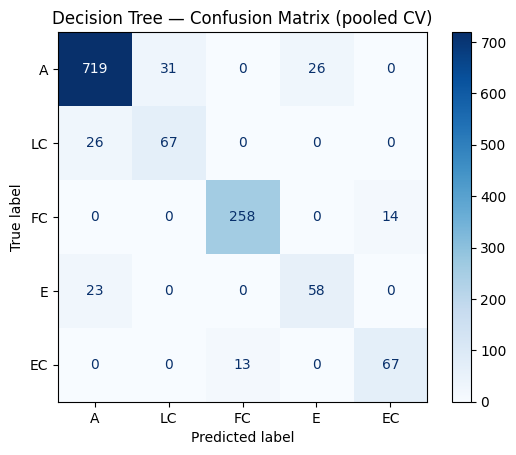

mean                                  \
                   Decision Tree K-Nearest Neighbors Naive Bayes   
accuracy                0.897857            0.821826    0.793417   
precision_macro         0.828917            0.713688    0.682224   
recall_macro            0.829642            0.603994    0.814649   
f1_macro                0.822695            0.641259    0.718867   
precision_weighted      0.903803            0.808842    0.859377   
recall_weighted         0.897857            0.821826    0.793417   
f1_weighted             0.898443            0.807815    0.808301   

                                                                  std  \
                   Random Forest Support Vector Machine Decision Tree   
accuracy                0.920910               0.866342      0.019826   
precision_macro         0.925826               0.653197      0.048774   
recall_macro            0.784981               0.634174      0.035853   
f1_macro                0.831016               0.635372      0.031408   
precision_weighted      0.922517               0.809990      0.017893   
recall_weighted         0.920910               0.866342      0.019826   
f1_weighted             0.912493               0.833372      0.018585   

                                                                  \
                   K-Nearest Neighbors Naive Bayes Random Forest   
accuracy                      0.029086    0.038889      0.023077   
precision_macro               0.076591    0.059942      0.037018   
recall_macro                  0.058883    0.063361      0.073229   
f1_macro                      0.067177    0.060165      0.060618   
precision_weighted            0.039471    0.031764      0.022166   
recall_weighted               0.029086    0.038889      0.023077   
f1_weighted                   0.033983    0.036182      0.027931   

                                           
                   Support Vector Machine  
accuracy                         0.019356  
precision_macro                  0.037226  
recall_macro                     0.045469  
f1_macro                         0.043222  
precision_weighted               0.020192  
recall_weighted                  0.019356  
f1_weighted                      0.021726

In [99]:
class_maps = {0.0: "A", 1.0: "LC", 2.0: "FC", 3.0: "E", 4.0: "EC"}
evaluate_models_cv(models, X, y, class_maps, n_splits=10, random_state=42)

Random Forest (RF) demonstrated the highest accuracy at 92\%, with an almost negligible variance . Models such as Support Vector Classifier, Decision Tree and K-Nearest Neighbor were close to RF with values of  87\% , 89\% and 83\% respectively, also variances can be ignored. The worst performing model is the Naive Bayes with 73\% of mean accuracy and a slightly higher variance but still not relevant as values are very low.

Once the results came with the original 11 features a feature reduction process was done to visualize which features are the ones contributing the most to the prediction of ICA and hence understand if a selection of the cheapest features could be used to predict with a similar performance as having the 11 features.

In [100]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

And return the importances


In [101]:
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

Now we plot them. This built-in method calculates the importance by the impurity on each level of the RF tree, by getting the accumulated it sorts out the features that are the most pure in the building of the trees



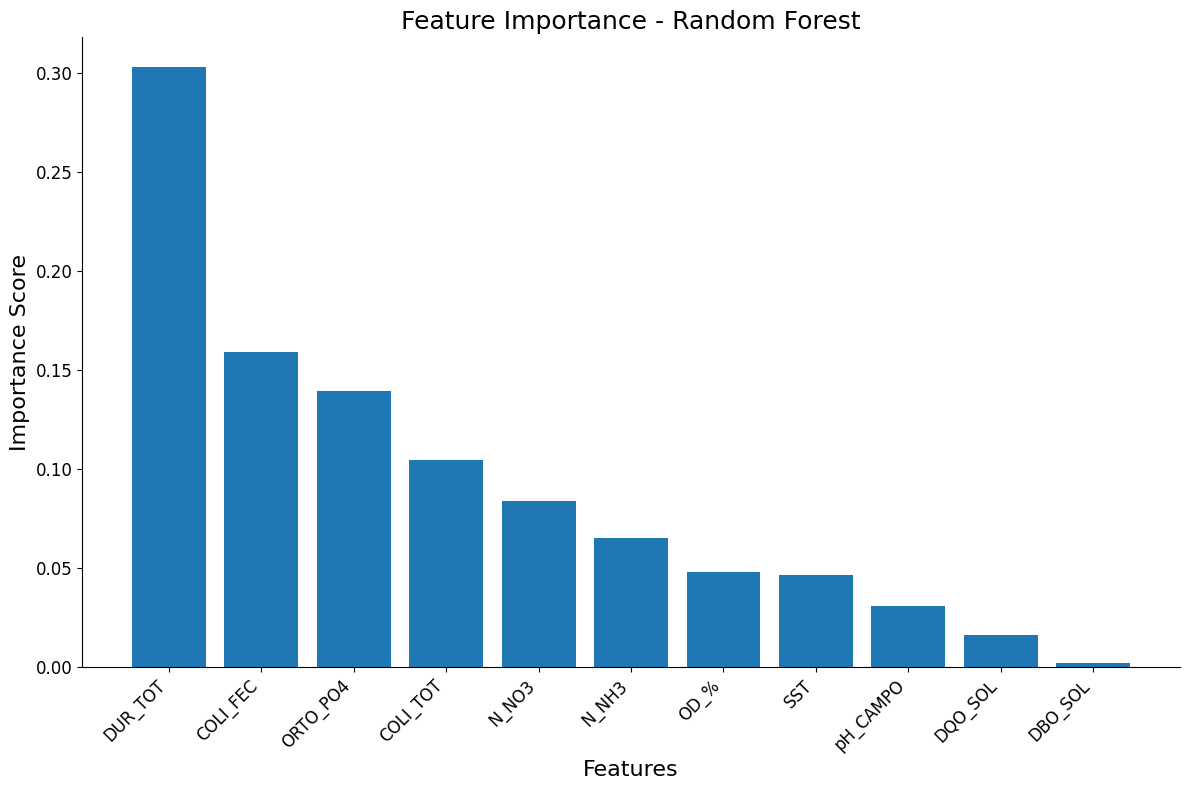

In [103]:
plt.figure(figsize=(12, 8))
plt.title("Feature Importance - Random Forest", fontsize=18)
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha="right")
plt.xlabel("Features", fontsize=16)
plt.ylabel("Importance Score", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
for spine in ["top", "right"]:
            plt.gca().spines[spine].set_visible(False)
plt.savefig( figures_dir / "rf_featureimportance.png", dpi=300, bbox_inches="tight")
plt.show()


As we can see the Dureza, SST, and amonio where the three most important features.

We are going to make a test with only five features

In [104]:
X_reduced = df_only_feat.drop(columns=['ICA_Class_Riego','ICA_Dinius','N_NO3','OD_%','DBO_SOL', 'DQO_SOL','COLI_TOT','COLI_FEC'], axis=1)

#X_reduced['log_sst'] = np.log(X_reduced['SST'])
#X_reduced = X_reduced.drop(columns=['SST'], axis=1)
y_reduced = df_only_feat['ICA_Class_Riego']

In [105]:
X_reduced.describe()

,pH_CAMPO,SST,N_NH3,ORTO_PO4,DUR_TOT
count,1302.000000,1302.000000,1302.000000,1302.000000,1302.000000
mean,7.742719,18.491444,0.174088,0.080338,484.886137
std,0.454103,19.020368,0.351112,0.183515,333.546195
min,6.200000,10.000000,0.003500,0.001000,64.470000
25%,7.400000,10.000000,0.049895,0.007479,268.317750
50%,7.800000,10.000000,0.083546,0.024086,345.250000
75%,8.100000,14.000000,0.138150,0.050940,642.420000
max,9.200000,140.000000,3.509876,1.571080,2076.537000


We do the same pipeline to try different models as before. We select the models

Set the cross validation to 10 splits

In [106]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

and run the code!


Random Forest — CV results (mean ± sd)
                     mean    std
accuracy            0.857  0.026
precision_macro     0.758  0.084
recall_macro        0.615  0.059
f1_macro            0.647  0.066
precision_weighted  0.833  0.035
recall_weighted     0.857  0.026
f1_weighted         0.829  0.030

Pooled classification report:
              precision    recall  f1-score   support

           A       0.85      0.98      0.91       776
          LC       0.88      0.40      0.55        93
          FC       0.91      0.97      0.94       272
           E       0.32      0.09      0.14        81
          EC       0.85      0.65      0.74        80

    accuracy                           0.86      1302
   macro avg       0.76      0.62      0.65      1302
weighted avg       0.83      0.86      0.83      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


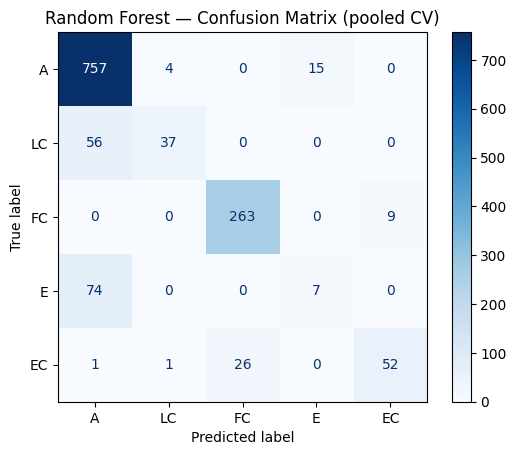


Support Vector Machine — CV results (mean ± sd)
                     mean    std
accuracy            0.854  0.016
precision_macro     0.693  0.054
recall_macro        0.581  0.029
f1_macro            0.599  0.033
precision_weighted  0.804  0.021
recall_weighted     0.854  0.016
f1_weighted         0.812  0.018

Pooled classification report:
              precision    recall  f1-score   support

           A       0.84      0.99      0.91       776
          LC       0.81      0.28      0.42        93
          FC       0.89      0.97      0.93       272
           E       0.00      0.00      0.00        81
          EC       0.85      0.66      0.75        80

    accuracy                           0.85      1302
   macro avg       0.68      0.58      0.60      1302
weighted avg       0.80      0.85      0.81      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


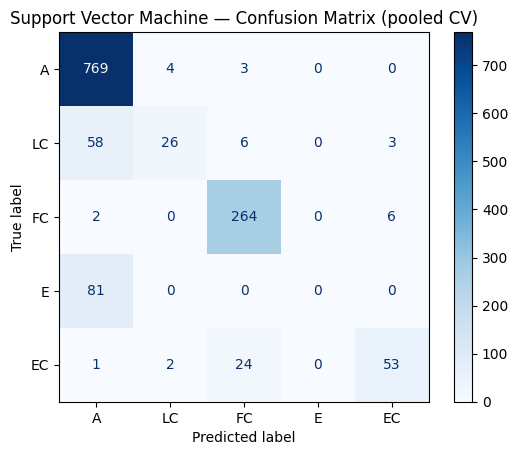


K-Nearest Neighbors — CV results (mean ± sd)
                     mean    std
accuracy            0.838  0.029
precision_macro     0.727  0.111
recall_macro        0.587  0.051
f1_macro            0.619  0.060
precision_weighted  0.816  0.045
recall_weighted     0.838  0.029
f1_weighted         0.812  0.031

Pooled classification report:
              precision    recall  f1-score   support

           A       0.85      0.96      0.90       776
          LC       0.60      0.31      0.41        93
          FC       0.90      0.96      0.93       272
           E       0.39      0.15      0.21        81
          EC       0.82      0.56      0.67        80

    accuracy                           0.84      1302
   macro avg       0.71      0.59      0.62      1302
weighted avg       0.81      0.84      0.81      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


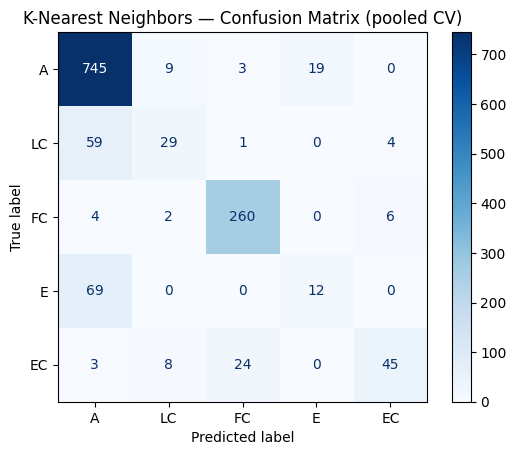


Naive Bayes — CV results (mean ± sd)
                     mean    std
accuracy            0.682  0.034
precision_macro     0.676  0.046
recall_macro        0.702  0.044
f1_macro            0.633  0.033
precision_weighted  0.818  0.027
recall_weighted     0.682  0.034
f1_weighted         0.715  0.029

Pooled classification report:
              precision    recall  f1-score   support

           A       0.90      0.60      0.72       776
          LC       0.59      0.37      0.45        93
          FC       0.84      0.96      0.89       272
           E       0.20      0.84      0.33        81
          EC       0.78      0.75      0.76        80

    accuracy                           0.68      1302
   macro avg       0.66      0.70      0.63      1302
weighted avg       0.81      0.68      0.71      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


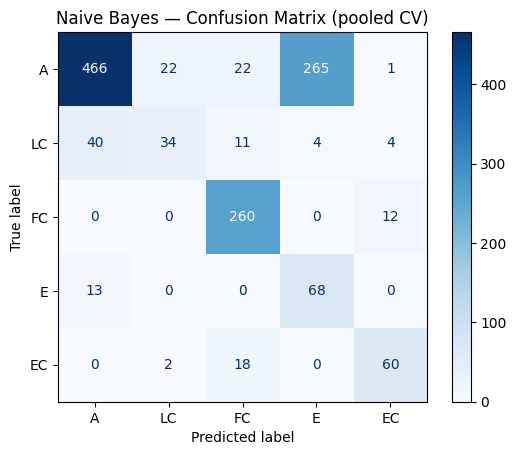


Decision Tree — CV results (mean ± sd)
                     mean    std
accuracy            0.783  0.028
precision_macro     0.613  0.054
recall_macro        0.608  0.052
f1_macro            0.607  0.050
precision_weighted  0.783  0.028
recall_weighted     0.783  0.028
f1_weighted         0.782  0.027

Pooled classification report:
              precision    recall  f1-score   support

           A       0.85      0.86      0.86       776
          LC       0.46      0.45      0.46        93
          FC       0.90      0.89      0.90       272
           E       0.17      0.16      0.17        81
          EC       0.64      0.68      0.66        80

    accuracy                           0.78      1302
   macro avg       0.61      0.61      0.61      1302
weighted avg       0.78      0.78      0.78      1302



/tmp/ipykernel_7775/4152551409.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


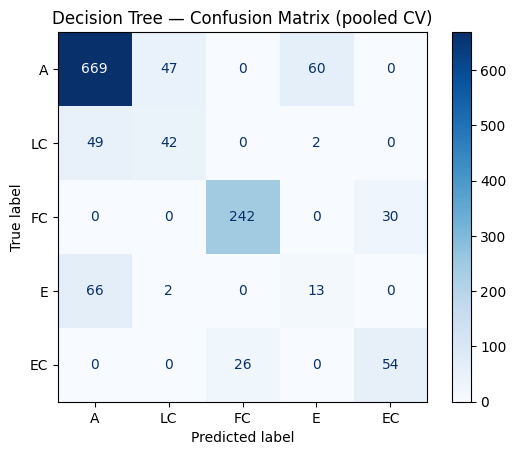

mean                                  \
                   Decision Tree K-Nearest Neighbors Naive Bayes   
accuracy                0.783435            0.837980    0.682049   
precision_macro         0.613474            0.727193    0.676380   
recall_macro            0.608136            0.587497    0.702147   
f1_macro                0.607139            0.618812    0.632678   
precision_weighted      0.782656            0.815944    0.817696   
recall_weighted         0.783435            0.837980    0.682049   
f1_weighted             0.781588            0.812237    0.715255   

                                                                  std  \
                   Random Forest Support Vector Machine Decision Tree   
accuracy                0.857152               0.854093      0.028394   
precision_macro         0.757610               0.692762      0.053550   
recall_macro            0.614586               0.580653      0.052010   
f1_macro                0.646931               0.598574      0.049942   
precision_weighted      0.832790               0.803561      0.028395   
recall_weighted         0.857152               0.854093      0.028394   
f1_weighted             0.829100               0.812188      0.026886   

                                                                  \
                   K-Nearest Neighbors Naive Bayes Random Forest   
accuracy                      0.028578    0.034449      0.026340   
precision_macro               0.110850    0.046204      0.084497   
recall_macro                  0.050966    0.043709      0.059497   
f1_macro                      0.060455    0.033068      0.066226   
precision_weighted            0.044715    0.026700      0.034798   
recall_weighted               0.028578    0.034449      0.026340   
f1_weighted                   0.030601    0.029234      0.030213   

                                           
                   Support Vector Machine  
accuracy                         0.015938  
precision_macro                  0.053612  
recall_macro                     0.028690  
f1_macro                         0.033248  
precision_weighted               0.021489  
recall_weighted                  0.015938  
f1_weighted                      0.018114

In [107]:
evaluate_models_cv(models, X_reduced, y_reduced, class_maps, n_splits=10, random_state=42)

In [108]:
import os, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

def _slug(text):
    return re.sub(r'[^A-Za-z0-9]+', '-', str(text)).strip('-').lower()

def evaluate_models_cv(
    models, X, y, class_mapping, n_splits=5, random_state=42,
    save_dir="figures", save_confusion=True, dpi=300, formats=("png","pdf"),
    show_plots=False
):
    """
    models: dict like {"Random Forest": RandomForestClassifier(...), ...}
    X, y: pandas objects
    class_mapping: e.g., {0.0: "A", 1.0: "LC", 2.0: "FC", 3.0: "E", 4.0: "EC"}

    Saves a pooled-CV confusion matrix per model as PNG/PDF (300 dpi) with
    article-ready styling (single-column size, clean labels).
    """
    os.makedirs(save_dir, exist_ok=True)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    label_order  = list(class_mapping.keys())
    target_names = [class_mapping[k] for k in label_order]

    all_model_summaries = {}

    for name, estimator in models.items():
        pipe = make_pipeline(StandardScaler(), estimator)

        fold_metrics = []
        pooled_true, pooled_pred = [], []

        for tr, te in skf.split(X, y):
            X_tr, X_te = X.iloc[tr], X.iloc[te]
            y_tr, y_te = y.iloc[tr], y.iloc[te]

            pipe.fit(X_tr, y_tr)
            y_hat = pipe.predict(X_te)

            # per-fold metrics
            acc = accuracy_score(y_te, y_hat)
            p_ma, r_ma, f_ma, _ = precision_recall_fscore_support(
                y_te, y_hat, average="macro", zero_division=0
            )
            p_wt, r_wt, f_wt, _ = precision_recall_fscore_support(
                y_te, y_hat, average="weighted", zero_division=0
            )

            fold_metrics.append({
                "accuracy": acc,
                "precision_macro": p_ma,
                "recall_macro": r_ma,
                "f1_macro": f_ma,
                "precision_weighted": p_wt,
                "recall_weighted": r_wt,
                "f1_weighted": f_wt,
            })

            pooled_true.append(y_te)
            pooled_pred.append(y_hat)

        # ---- summarize across folds (mean ± sd) ----
        fm = pd.DataFrame(fold_metrics)
        summary = pd.DataFrame({
            "mean": fm.mean(numeric_only=True),
            "std":  fm.std(ddof=1, numeric_only=True)
        })
        all_model_summaries[name] = summary

        print(f"\n{name} — CV results (mean ± sd)")
        print((summary.applymap(lambda v: f"{v:.3f}")).to_string())

        # ---- pooled predictions across folds ----
        y_true = pd.concat(pooled_true).values
        y_pred = np.concatenate(pooled_pred)

        print("\nPooled classification report:")
        print(classification_report(
            y_true, y_pred,
            labels=label_order,
            target_names=target_names,
            zero_division=0
        ))

        # ---- confusion matrix (counts) ----
        cm = confusion_matrix(y_true, y_pred, labels=label_order)

        # Article-ready styling: single-column width (~3.35in), clean axes, 8–9 pt fonts
        sns.set_theme(style="white", font_scale=0.95)
        fig, ax = plt.subplots(figsize=(3.35, 3.35))  # ~85 mm single-column figure

        sns.heatmap(
            cm, ax=ax, cmap="Blues", annot=True, fmt="d", cbar=False,
            square=True, linewidths=0.5, linecolor="white",
            annot_kws={"fontsize":8}
        )
        ax.set_xlabel("Predicted class", fontsize=9)
        ax.set_ylabel("True class", fontsize=9)
        ax.set_xticklabels(target_names, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(target_names, rotation=0, fontsize=8)

        # Minimal frame for print
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.set_title(f"{name}: Confusion Matrix (pooled CV)", fontsize=9, pad=6)
        plt.tight_layout(pad=0.5)

        # Save at 300 dpi (PNG + PDF)
        if save_confusion:
            base = os.path.join(save_dir, f"cm_{_slug(name)}_pooled_cv")
            for ext in formats:
                fig.savefig(f"{base}.{ext}", dpi=dpi, bbox_inches="tight", pad_inches=0.02)

        if show_plots:
            plt.show()
        plt.close(fig)

    # nice multi-index dataframe: (model, metric) x (mean, std)
    results_df = pd.concat(all_model_summaries, axis=1).swaplevel(axis=1).sort_index(axis=1)
    return results_df


In [109]:
evaluate_models_cv(models, X_reduced, y_reduced, class_maps, n_splits=10, random_state=42)


Random Forest — CV results (mean ± sd)
                     mean    std
accuracy            0.857  0.026
precision_macro     0.758  0.084
recall_macro        0.615  0.059
f1_macro            0.647  0.066
precision_weighted  0.833  0.035
recall_weighted     0.857  0.026
f1_weighted         0.829  0.030

Pooled classification report:
              precision    recall  f1-score   support

           A       0.85      0.98      0.91       776
          LC       0.88      0.40      0.55        93
          FC       0.91      0.97      0.94       272
           E       0.32      0.09      0.14        81
          EC       0.85      0.65      0.74        80

    accuracy                           0.86      1302
   macro avg       0.76      0.62      0.65      1302
weighted avg       0.83      0.86      0.83      1302



/tmp/ipykernel_7775/3583343418.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())



Support Vector Machine — CV results (mean ± sd)
                     mean    std
accuracy            0.854  0.016
precision_macro     0.693  0.054
recall_macro        0.581  0.029
f1_macro            0.599  0.033
precision_weighted  0.804  0.021
recall_weighted     0.854  0.016
f1_weighted         0.812  0.018

Pooled classification report:
              precision    recall  f1-score   support

           A       0.84      0.99      0.91       776
          LC       0.81      0.28      0.42        93
          FC       0.89      0.97      0.93       272
           E       0.00      0.00      0.00        81
          EC       0.85      0.66      0.75        80

    accuracy                           0.85      1302
   macro avg       0.68      0.58      0.60      1302
weighted avg       0.80      0.85      0.81      1302


K-Nearest Neighbors — CV results (mean ± sd)
                     mean    std
accuracy            0.838  0.029
precision_macro     0.727  0.111
recall_macro        0.

/tmp/ipykernel_7775/3583343418.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())
/tmp/ipykernel_7775/3583343418.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())



Naive Bayes — CV results (mean ± sd)
                     mean    std
accuracy            0.682  0.034
precision_macro     0.676  0.046
recall_macro        0.702  0.044
f1_macro            0.633  0.033
precision_weighted  0.818  0.027
recall_weighted     0.682  0.034
f1_weighted         0.715  0.029

Pooled classification report:
              precision    recall  f1-score   support

           A       0.90      0.60      0.72       776
          LC       0.59      0.37      0.45        93
          FC       0.84      0.96      0.89       272
           E       0.20      0.84      0.33        81
          EC       0.78      0.75      0.76        80

    accuracy                           0.68      1302
   macro avg       0.66      0.70      0.63      1302
weighted avg       0.81      0.68      0.71      1302


Decision Tree — CV results (mean ± sd)
                     mean    std
accuracy            0.783  0.028
precision_macro     0.613  0.054
recall_macro        0.608  0.052
f1_mac

/tmp/ipykernel_7775/3583343418.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())
/tmp/ipykernel_7775/3583343418.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((summary.applymap(lambda v: f"{v:.3f}")).to_string())


mean                                  \
                   Decision Tree K-Nearest Neighbors Naive Bayes   
accuracy                0.783435            0.837980    0.682049   
precision_macro         0.613474            0.727193    0.676380   
recall_macro            0.608136            0.587497    0.702147   
f1_macro                0.607139            0.618812    0.632678   
precision_weighted      0.782656            0.815944    0.817696   
recall_weighted         0.783435            0.837980    0.682049   
f1_weighted             0.781588            0.812237    0.715255   

                                                                  std  \
                   Random Forest Support Vector Machine Decision Tree   
accuracy                0.857152               0.854093      0.028394   
precision_macro         0.757610               0.692762      0.053550   
recall_macro            0.614586               0.580653      0.052010   
f1_macro                0.646931               0.598574      0.049942   
precision_weighted      0.832790               0.803561      0.028395   
recall_weighted         0.857152               0.854093      0.028394   
f1_weighted             0.829100               0.812188      0.026886   

                                                                  \
                   K-Nearest Neighbors Naive Bayes Random Forest   
accuracy                      0.028578    0.034449      0.026340   
precision_macro               0.110850    0.046204      0.084497   
recall_macro                  0.050966    0.043709      0.059497   
f1_macro                      0.060455    0.033068      0.066226   
precision_weighted            0.044715    0.026700      0.034798   
recall_weighted               0.028578    0.034449      0.026340   
f1_weighted                   0.030601    0.029234      0.030213   

                                           
                   Support Vector Machine  
accuracy                         0.015938  
precision_macro                  0.053612  
recall_macro                     0.028690  
f1_macro                         0.033248  
precision_weighted               0.021489  
recall_weighted                  0.015938  
f1_weighted                      0.018114

In addition we use the RFECV method to iteratively remove one variable at a time and train a Random Forest, to determine the contribution of the number of variables to the model.

In [112]:
from sklearn.feature_selection import RFECV, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def run_rfecv_diagnostics(X, y, plot=True):
    # 1. Define model
    est = RandomForestRegressor(
        n_estimators=100, max_features="sqrt",
        random_state=0, n_jobs=-1
    )

    # 2. Run RFECV
    cv = KFold(n_splits=10, shuffle=True, random_state=0)
    rfecv = RFECV(
        estimator=est, step=1,
        min_features_to_select=1,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    rfecv.fit(X, y)

    # 3. Extract best number and final selected features
    best_n = rfecv.n_features_
    best_features = list(X.columns[rfecv.support_])

    # 4. Run manual RFE for each feature count
    feature_ranking = {}
    for n in range(1, X.shape[1]+1):
        rfe = RFE(estimator=est, n_features_to_select=n, step=1)
        rfe.fit(X, y)
        selected = list(X.columns[rfe.support_])
        feature_ranking[n] = selected

    # 5. Plot performance
    if plot:
        rmse_scores = -rfecv.cv_results_["mean_test_score"]
        plt.figure(figsize=(12, 8))
        plt.plot(range(1, len(rmse_scores)+1), rmse_scores, marker="o")
        plt.xlabel("Number of Features Retained", fontsize=16)
        plt.ylabel("CV RMSE", fontsize=16)
        plt.title("RFECV – Performance vs. Feature Count", fontsize=18)
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.tick_params(axis='both', labelsize=12)
        plt.tight_layout()

        for spine in ["top", "right"]:
            plt.gca().spines[spine].set_visible(False)

        plt.savefig( figures_dir / "rfecv_water.png", dpi=300, bbox_inches="tight")
        plt.show()

    # 6. Return everything
    return {
        "best_n": best_n,
        "best_features": best_features,
        "all_feature_sets": feature_ranking,
        "rmse_scores": -rfecv.cv_results_["mean_test_score"]
    }


We run the test


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/opt/conda/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/conda/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/conda/lib/python3.11

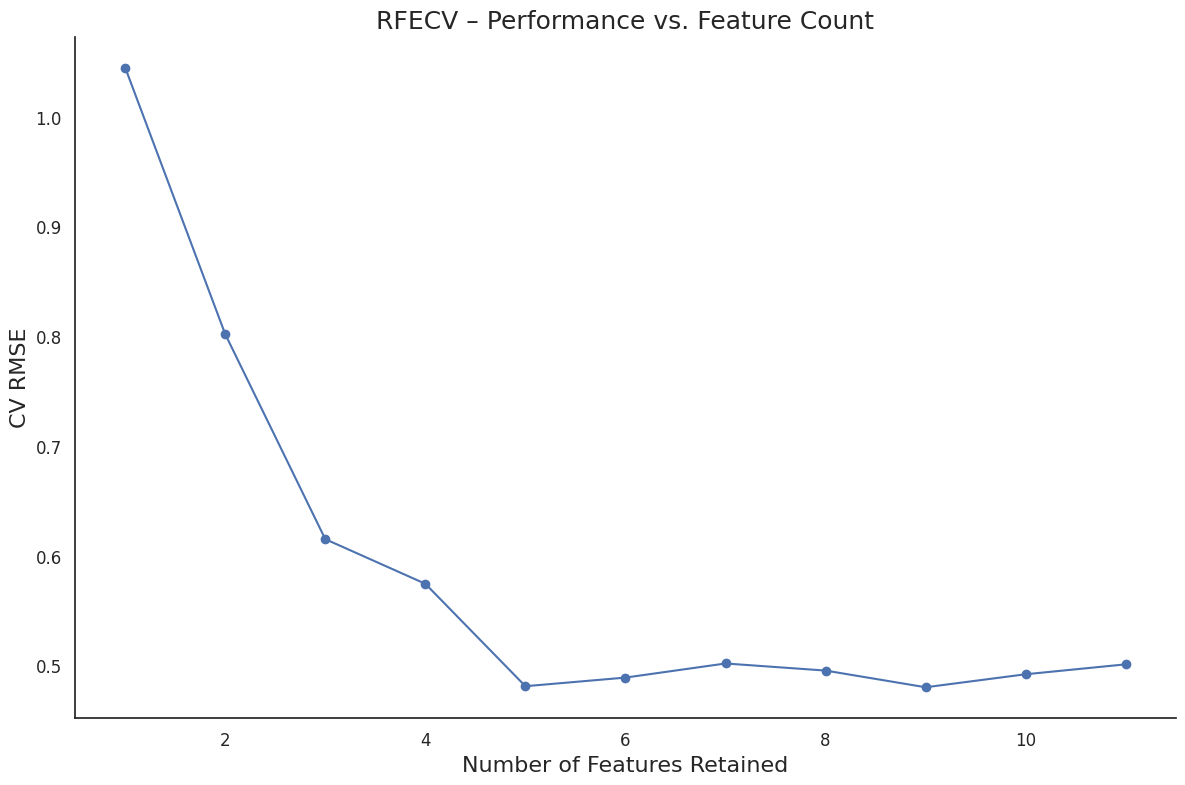

In [113]:
results = run_rfecv_diagnostics(X, y)

We print the results, and notice that DUR_TOT and pH_CAMPO are the most important features, followed by COLI_TOT and ORTO_PO4.

In [ ]:
print("🔹 Best number of features:", results["best_n"])
print("🔹 Best features:", results["best_features"])
print("🔹 Features selected when n=2:", results["all_feature_sets"][2])
print("🔹 Features selected when n=4:", results["all_feature_sets"][4])
print("🔹 Features selected when n=6:", results["all_feature_sets"][6])
print("🔹 Features selected when n=8:", results["all_feature_sets"][8])
